In [1]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import sweetviz as sv
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import warnings
from scipy.stats import zscore, mode
from sklearn.metrics import (silhouette_samples,silhouette_score,make_scorer,mean_absolute_error, r2_score, mean_squared_error,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)
from sklearn.base import (BaseEstimator,TransformerMixin,ClassifierMixin,RegressorMixin)
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, BaseCrossValidator, KFold, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import joblib
from joblib import load
import os
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans, silhouette_score as ts_silhouette_score
import shap
from lime import lime_tabular
from sklearn.model_selection import GroupKFold

In [2]:
# Cargar los datos desde el archivo Excel
file_path = 'C:/Users/Andy/OneDrive/Desktop/MCD/Tesis/Datos_fuente_Bloomberg/en valores/serie completa 2014-2024/Dataset/dataset_completo.xlsx'
df = pd.read_excel(file_path, sheet_name='dataset')

In [3]:
df.head()

,Empresa,Fecha,P_E,P_B,P_TB,P_S,P_CF,P_FCF,P_Share,ROCE_sp,...,Efectivo y equiv_l,CPI,CPI_Exp_mediana,CPI_Exp_promedio,Fed Funds Rate,Fed Funds Rate_Exp_mediana,Fed Funds Rate_Exp_promedio,Non farm payrolls,Non farm payrolls_Exp_mediana,Non farm payrolls_Exp_promedio
0,FLWS US Equity,20140930,31.7207,2.5643,6.1415,0.6062,10.3190,21.6093,7.19,5.886400,...,1.314000,1.7,0.019,0.0191,0.25,0.0025,0.0025,307,230k,226.13k
1,FLWS US Equity,20141031,35.4266,2.8638,6.859,0.677,11.5246,24.1339,8.03,8.881198,...,2.610333,1.7,0.016,0.0162,0.25,0.0025,0.0025,240,215k,216.22k
2,FLWS US Equity,20141128,37.7207,3.0493,7.3032,0.7208,12.2709,25.6967,8.55,9.469145,...,3.906667,1.3,0.016,0.0157,0.25,0.0025,0.0025,284,235k,236.62k
3,FLWS US Equity,20141231,11.3711,2.3843,8.1913,0.5153,2.6214,3.0449,8.24,8.721900,...,5.203000,0.8,0.014,0.0142,0.25,0.0025,0.0025,278,230k,229.16k
4,FLWS US Equity,20150130,10.8881,2.283,7.8433,0.4934,2.5100,2.9155,7.89,7.711122,...,4.188000,-0.1,0.007,0.0069,0.25,0.0025,0.0025,196,240k,234.73k


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166440 entries, 0 to 166439
Data columns (total 42 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Empresa                         166440 non-null  object 
 1   Fecha                           166440 non-null  int64  
 2   P_E                             87792 non-null   float64
 3   P_B                             119348 non-null  object 
 4   P_TB                            92514 non-null   object 
 5   P_S                             117703 non-null  object 
 6   P_CF                            95713 non-null   float64
 7   P_FCF                           69291 non-null   object 
 8   P_Share                         131345 non-null  object 
 9   ROCE_sp                         115613 non-null  float64
 10  ROCE_l                          115613 non-null  float64
 11  EBIT_sp                         115176 non-null  float64
 12  EBIT_l          

In [5]:
# Quitar "k" de las columnas "Non farm payrolls_Exp_mediana" y "Non farm payrolls_Exp_promedio"
df['Non farm payrolls_Exp_mediana'] = df['Non farm payrolls_Exp_mediana'].astype(str).str.replace('k', '')
df['Non farm payrolls_Exp_promedio'] = df['Non farm payrolls_Exp_promedio'].astype(str).str.replace('k', '')

# Convertir las columnas a valores numéricos
df['Non farm payrolls_Exp_mediana'] = pd.to_numeric(df['Non farm payrolls_Exp_mediana'], errors='coerce')
df['Non farm payrolls_Exp_promedio'] = pd.to_numeric(df['Non farm payrolls_Exp_promedio'], errors='coerce')
df['P_B'] = pd.to_numeric(df['P_B'], errors='coerce')
df['P_TB'] = pd.to_numeric(df['P_TB'], errors='coerce')
df['P_S'] = pd.to_numeric(df['P_S'], errors='coerce')
df['P_FCF'] = pd.to_numeric(df['P_FCF'], errors='coerce')
df['P_Share'] = pd.to_numeric(df['P_Share'], errors='coerce')

In [6]:
# Convertir la columna de fecha a formato datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y%m%d')

# Extraer características temporales relevantes
df['mes'] = df['Fecha'].dt.month
df['año'] = df['Fecha'].dt.year
df['periodo'] = df['Fecha'].dt.to_period('M')

In [7]:
# Convertir CPI y Fed Funds Rate a decimales
df['CPI'] = df['CPI'] / 100
df['Fed Funds Rate'] = df['Fed Funds Rate'] / 100

In [8]:
# Calcular diferencias en puntos básicos
df['dif_CPI_mediana'] = (df['CPI'] - df['CPI_Exp_mediana']) * 10000
df['dif_CPI_promedio'] = (df['CPI'] - df['CPI_Exp_promedio']) * 10000

df['dif_FFR_mediana'] = (df['Fed Funds Rate'] - df['Fed Funds Rate_Exp_mediana']) * 10000
df['dif_FFR_promedio'] = (df['Fed Funds Rate'] - df['Fed Funds Rate_Exp_promedio']) * 10000

# Calcular diferencia
df['dif_NFP_mediana'] = (df['Non farm payrolls'] - df['Non farm payrolls_Exp_mediana'])
df['dif_NFP_promedio'] = (df['Non farm payrolls'] - df['Non farm payrolls_Exp_promedio'])

In [9]:
# Lista de columnas numéricas para análisis con mensualización lineal de los ratios 
# y variables macroeconómicas calculadas con mediana
columnas_numericas_lineal_mediana= [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_l',
    'EBIT_l',
    'Total Activos_l',
    'Deuda a LP_l',
    'ROA_l',
    'Beneficio neto_l',
    'ROI_l',
    'EV_l',
    'Cap de mercado_l',
    'Deuda a CP_l',
    'Efectivo y equiv_l',
    'dif_CPI_mediana',
    'dif_FFR_mediana',
    'dif_NFP_mediana'
]

In [10]:
# Lista de columnas numéricas para análisis con mensualización spline de los ratios 
# y variables macroeconómicas calculadas con mediana
columnas_numericas_spline_mediana = [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_sp',
    'EBIT_sp',
    'Total Activos_sp',
    'Deuda a LP_sp',
    'ROA_sp',
    'Beneficio neto_sp',
    'ROI_sp',
    'EV_sp',
    'Cap de mercado_sp',
    'Deuda a CP_sp',
    'Efectivo y equiv_sp',
    'dif_CPI_mediana',
    'dif_FFR_mediana',
    'dif_NFP_mediana'
]

In [11]:
# Lista de columnas numéricas para análisis con mensualización lineal de los ratios 
# y variables macroeconómicas calculadas con promedio
columnas_numericas_lineal_promedio = [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_l',
    'EBIT_l',
    'Total Activos_l',
    'Deuda a LP_l',
    'ROA_l',
    'Beneficio neto_l',
    'ROI_l',
    'EV_l',
    'Cap de mercado_l',
    'Deuda a CP_l',
    'Efectivo y equiv_l',
    'dif_CPI_promedio',
    'dif_FFR_promedio',
    'dif_NFP_promedio'
]

In [12]:
# Lista de columnas numéricas para análisis con mensualización spline de los ratios 
# y variables macroeconómicas calculadas con promedio
columnas_numericas_spline_promedio = [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_sp',
    'EBIT_sp',
    'Total Activos_sp',
    'Deuda a LP_sp',
    'ROA_sp',
    'Beneficio neto_sp',
    'ROI_sp',
    'EV_sp',
    'Cap de mercado_sp',
    'Deuda a CP_sp',
    'Efectivo y equiv_sp',
    'dif_CPI_promedio',
    'dif_FFR_promedio',
    'dif_NFP_promedio'
]

In [13]:
listas_columnas = {
    'lineal_mediana': columnas_numericas_lineal_mediana,
    'spline_mediana': columnas_numericas_spline_mediana,
    'lineal_promedio': columnas_numericas_lineal_promedio,
    'spline_promedio': columnas_numericas_spline_promedio
}

In [14]:
listas_columnas

{'lineal_mediana': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_l',
  'EBIT_l',
  'Total Activos_l',
  'Deuda a LP_l',
  'ROA_l',
  'Beneficio neto_l',
  'ROI_l',
  'EV_l',
  'Cap de mercado_l',
  'Deuda a CP_l',
  'Efectivo y equiv_l',
  'dif_CPI_mediana',
  'dif_FFR_mediana',
  'dif_NFP_mediana'],
 'spline_mediana': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_sp',
  'EBIT_sp',
  'Total Activos_sp',
  'Deuda a LP_sp',
  'ROA_sp',
  'Beneficio neto_sp',
  'ROI_sp',
  'EV_sp',
  'Cap de mercado_sp',
  'Deuda a CP_sp',
  'Efectivo y equiv_sp',
  'dif_CPI_mediana',
  'dif_FFR_mediana',
  'dif_NFP_mediana'],
 'lineal_promedio': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_l',
  'EBIT_l',
  'Total Activos_l',
  'Deuda a LP_l',
  'ROA_l',
  'Beneficio neto_l',
  'ROI_l',
  'EV_l',
  'Cap de mercado_l',
  'Deuda a CP_l',
  'Efectivo y equiv_l',
  'dif_CPI_promedio',
  'dif_FFR_promedio',
  'dif_NFP_promedio'],
 'spline_promedio': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_sp',
  'E

In [15]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 1: Importaciones y Funciones Auxiliares                  │
# └─────────────────────────────────────────────────────────────────┘
import pandas as pd
import numpy as np

def pct_missing_by_column(df, columns):
    """Devuelve % de NaNs por columna, ordenado descendente."""
    return (df[columns].isna().mean() * 100).sort_values(ascending=False)

def pct_missing_by_group(df, group_col, features):
    """Devuelve Series con el máximo % de NaNs en cualquier feature por grupo."""
    missing = df.groupby(group_col)[features]\
                .apply(lambda g: g.isna().mean()*100)
    return missing.max(axis=1)

def filter_companies_by_target_missing(df, group_col, target_col):
    """Filtra y devuelve df sin empresas que tengan ANY NaN en target_col."""
    ok = ~df.groupby(group_col)[target_col].apply(lambda s: s.isna().any())
    valid_companies = ok[ok].index
    return df[df[group_col].isin(valid_companies)].copy()

def impute_by_group(df, group_col, features, methods=('ffill',), fill_value=0): # <-- Cambiar default
    """Imputa NaNs por grupo usando .ffill() y termina con fillna(fill_value)."""
    df2 = df.sort_values([group_col, 'Fecha']).copy()
    for m in methods:
        df2[features] = df2.groupby(group_col)[features]\
                            .transform(lambda g: getattr(g, m)())
    return df2.fillna(fill_value)

def create_lags(df, group_col, date_col, features, lag=1):
    """Genera columnas de lag para cada feature dentro de cada grupo."""
    df2 = df.sort_values([group_col, date_col]).copy()
    for feat in features:
        df2[f"{feat}_lag{lag}"] = df2.groupby(group_col)[feat].shift(lag)
    return df2


In [16]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 3: Conversión Masiva a Numérico                         │
# └─────────────────────────────────────────────────────────────────┘
# Crear set de features base (sin 'Empresa' ni 'Fecha'), añadir 'P_E' si existe
features_base = {
    col for cols in listas_columnas.values()
            for col in cols if col not in ('Empresa','Fecha')
}
if 'P_E' in df.columns:
    features_base.add('P_E')
numeric_cols = [c for c in sorted(features_base) if c in df.columns]

# Vectorizado
nan_before = df[numeric_cols].isna().sum()
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
nan_after = df[numeric_cols].isna().sum()
print("NaNs añadidos:", (nan_after - nan_before).sum())

NaNs añadidos: 0


In [17]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 4: Filtrar Empresas con NaNs en el Target P_E           │
# └─────────────────────────────────────────────────────────────────┘
df_no_PE_NaN = filter_companies_by_target_missing(df, 'Empresa', 'P_E')
print("Empresas tras filtrar P_E NaN:", df_no_PE_NaN['Empresa'].nunique())

Empresas tras filtrar P_E NaN: 403


In [18]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 5: Excluir Columnas Críticas con Demasiados NaNs        │
# └─────────────────────────────────────────────────────────────────┘
col_pct = pct_missing_by_column(df_no_PE_NaN, numeric_cols)
col_pct

EBIT_sp                29.698098
EBIT_l                 29.698098
EV_sp                  28.662117
EV_l                   28.662117
Deuda a CP_l            6.952026
Deuda a CP_sp           6.952026
ROCE_sp                 3.196857
ROCE_l                  3.196857
ROI_sp                  2.045079
ROI_l                   2.045079
Deuda a LP_sp           1.774194
Deuda a LP_l            1.774194
ROA_l                   1.600496
ROA_sp                  1.600496
P_B                     1.565343
Total Activos_sp        1.428867
Total Activos_l         1.428867
Efectivo y equiv_l      1.418528
Efectivo y equiv_sp     1.418528
Beneficio neto_sp       1.296526
Beneficio neto_l        1.296526
Cap de mercado_sp       1.265509
Cap de mercado_l        1.265509
P_S                     0.051696
P_Share                 0.002068
P_E                     0.000000
dif_CPI_mediana         0.000000
dif_CPI_promedio        0.000000
dif_FFR_mediana         0.000000
dif_FFR_promedio        0.000000
dif_NFP_me

In [19]:
umbral_col = 5.0   # % máximo de NaNs tolerable
cols_to_exclude = col_pct[col_pct > umbral_col].index.tolist()
features_kept = [c for c in numeric_cols if c not in cols_to_exclude]
print(f"Columnas excluidas (> {umbral_col}% NaNs):", cols_to_exclude)

Columnas excluidas (> 5.0% NaNs): ['EBIT_sp', 'EBIT_l', 'EV_sp', 'EV_l', 'Deuda a CP_l', 'Deuda a CP_sp']


In [20]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 6: Excluir Empresas con Demasiados NaNs en Features     │
# └─────────────────────────────────────────────────────────────────┘
umbral_grp = 10   # % máximo de NaNs por empresa
grp_pct = pct_missing_by_group(df_no_PE_NaN, 'Empresa', features_kept)
empresas_final = grp_pct[grp_pct <= umbral_grp].index.tolist()
df_final = df_no_PE_NaN[df_no_PE_NaN['Empresa'].isin(empresas_final)].copy()
print("Empresas finales (<= {umbral_grp}% NaNs):", len(empresas_final))


Empresas finales (<= {umbral_grp}% NaNs): 381


In [21]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 7: Imputar NaNs Restantes                                │
# └─────────────────────────────────────────────────────────────────┘
df_imputed = impute_by_group(df_final, 'Empresa', features_kept)
print("NaNs totales después de imputar:", df_imputed[features_kept].isna().sum().sum())


NaNs totales después de imputar: 0


In [22]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 8: Crear DataFrames con Lag (Incluyendo P_E_lag1 como feature) │
# └─────────────────────────────────────────────────────────────────┘
dfs_shifted = {}
LAG_VALUE_EXPERIMENT = 1 # Define el lag a usar (ej. 1 para _lag1)

# Asunciones:
# 1. df_imputed: DataFrame con datos limpios, incluyendo 'Empresa', 'Fecha', 'P_E' y las columnas base.
# 2. listas_columnas: Diccionario {metodo: [lista_de_columnas_base_para_ese_metodo]}
# 3. features_kept: Lista de columnas que pasaron filtros de NaNs (debe incluir 'P_E' si quieres su lag).
#    Si 'P_E' no está en features_kept porque se trató solo como target, necesitaremos añadirlo
#    específicamente para la creación de su lag.

# Asegurarse de que 'P_E' esté considerado para laggear si queremos P_E_lag1
# Esto es importante si 'features_kept' no incluye 'P_E' porque se manejó solo como target antes.
features_kept_for_lags = features_kept.copy() # Trabajar con una copia
if 'P_E' not in features_kept_for_lags and 'P_E' in df_imputed.columns:
    print("  Nota Bloque 8: Añadiendo 'P_E' a la lista de features a considerar para lags, para poder generar P_E_lagN.")
    features_kept_for_lags.append('P_E')
    features_kept_for_lags = sorted(list(set(features_kept_for_lags)))


for metodo, cols_originales_del_metodo in listas_columnas.items():
    print(f"\nProcesando lags para Método: {metodo}")
    # 1. Determinar las features base para este método que SÍ existen y pasaron filtros
    #    Estas son las features (EXCLUYENDO IDs y el target P/E original) para las que se crearán lags.
    #    PERO, si queremos P_E_lag1, P_E debe estar entre las features para las que se crea un lag.
    
    features_base_para_este_metodo = [
        col for col in cols_originales_del_metodo # Empezar con las definidas para el método
        if col in features_kept_for_lags  # Solo las que pasaron el filtro de NaNs global (y ahora incluye P_E)
           and col in df_imputed.columns    # Y existen en df_imputed
           and col not in ('Empresa', 'Fecha') # Excluir IDs
           # NO excluimos 'P_E' aquí porque queremos generar P_E_lagN
    ]

    if not features_base_para_este_metodo:
        print(f"  Método '{metodo}': No hay features base válidas (de 'features_kept_for_lags') para crear lags. Se omite.")
        continue
    
    print(f"  Features base para {metodo} que se usarán para generar lags ({len(features_base_para_este_metodo)}): {features_base_para_este_metodo[:5]}...")

    # 2. Preparar el DataFrame base para la función create_lags
    #    Necesita 'Empresa', 'Fecha', y TODAS las 'features_base_para_este_metodo' (que ahora incluye 'P_E')
    columnas_para_df_con_lags = ['Empresa', 'Fecha']
    # Añadir las features base, asegurando que 'P_E' (target original) también esté si no está ya en features_base_para_este_metodo
    # (aunque debería estarlo si se añadió a features_kept_for_lags)
    columnas_para_df_con_lags.extend(f for f in features_base_para_este_metodo if f not in columnas_para_df_con_lags)
    if 'P_E' not in columnas_para_df_con_lags and 'P_E' in df_imputed.columns: # Asegurar que P_E (target) esté para el join final
        columnas_para_df_con_lags.append('P_E')

    columnas_para_df_con_lags = [col for col in columnas_para_df_con_lags if col in df_imputed.columns] # Solo existentes
    
    if not all(essential_col in columnas_para_df_con_lags for essential_col in ['Empresa', 'Fecha']):
        print(f"  Método '{metodo}': Faltan 'Empresa' o 'Fecha'. Se omite.")
        continue
        
    df_para_crear_lags = df_imputed[columnas_para_df_con_lags].copy()

    # 3. Generar los lags para TODAS las features_base_para_este_metodo (incluyendo P_E)
    #    La función create_lags añadirá columnas como 'FeatureX_lag1', 'P_E_lag1'
    df_con_lags_generados = create_lags(df_para_crear_lags, 'Empresa', 'Fecha', features_base_para_este_metodo, lag=LAG_VALUE_EXPERIMENT)

    # 4. Definir las columnas de lag que se usarán como predictores finales
    #    Esto incluye P_E_lagN y los lags de las otras features.
    predictor_cols_finales_con_lag = [f"{feat}_lag{LAG_VALUE_EXPERIMENT}" for feat in features_base_para_este_metodo]
    
    # Asegurar que estas columnas de lag realmente se generaron
    predictor_cols_finales_existentes = [col for col in predictor_cols_finales_con_lag if col in df_con_lags_generados.columns]

    if not predictor_cols_finales_existentes:
         print(f"  Método '{metodo}': No se generaron columnas de lag válidas. Se omite.")
         continue
    
    # 5. Eliminar filas donde CUALQUIERA de los predictores de lag finales sea NaN
    rows_before_dropna = len(df_con_lags_generados)
    df_con_lags_generados.dropna(subset=predictor_cols_finales_existentes, inplace=True)
    rows_after_dropna = len(df_con_lags_generados)
    print(f"  {metodo}: Se eliminaron {rows_before_dropna - rows_after_dropna} filas por NaNs en lags.")


    if df_con_lags_generados.empty:
        print(f"  Método '{metodo}': El DataFrame quedó vacío después de crear lags y dropna.")
    else:
        # El DataFrame final para este método contendrá:
        # 'Empresa', 'Fecha', 'P_E' (target actual), y todas las 'predictor_cols_finales_existentes'
        # (que incluye P_E_lagN y los lags de otras features)
        
        # Seleccionar solo las columnas necesarias para el siguiente bloque (experimentos)
        columnas_a_mantener_en_dfs_shifted = ['Empresa', 'Fecha']
        if 'P_E' in df_con_lags_generados.columns: # Target
            columnas_a_mantener_en_dfs_shifted.append('P_E')
        columnas_a_mantener_en_dfs_shifted.extend(predictor_cols_finales_existentes) # Todas las features _lagN
        
        # Eliminar duplicados en la lista de columnas por si acaso
        columnas_a_mantener_en_dfs_shifted = sorted(list(set(col for col in columnas_a_mantener_en_dfs_shifted if col in df_con_lags_generados.columns)))

        dfs_shifted[metodo] = df_con_lags_generados[columnas_a_mantener_en_dfs_shifted].copy()
        
        print(f"  Método '{metodo}' (dfs_shifted): {dfs_shifted[metodo].shape[0]} filas, {dfs_shifted[metodo].shape[1]} columnas.")
        print(f"    Predictores finales (lags): {len(predictor_cols_finales_existentes)} {predictor_cols_finales_existentes[:5]}...")
        if f'P_E_lag{LAG_VALUE_EXPERIMENT}' in predictor_cols_finales_existentes:
            print(f"    ¡Confirmado! 'P_E_lag{LAG_VALUE_EXPERIMENT}' está incluido como predictor.")


Procesando lags para Método: lineal_mediana
  Features base para lineal_mediana que se usarán para generar lags (15): ['P_E', 'P_B', 'P_S', 'P_Share', 'ROCE_l']...
  lineal_mediana: Se eliminaron 381 filas por NaNs en lags.
  Método 'lineal_mediana' (dfs_shifted): 45339 filas, 18 columnas.
    Predictores finales (lags): 15 ['P_E_lag1', 'P_B_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROCE_l_lag1']...
    ¡Confirmado! 'P_E_lag1' está incluido como predictor.

Procesando lags para Método: spline_mediana
  Features base para spline_mediana que se usarán para generar lags (15): ['P_E', 'P_B', 'P_S', 'P_Share', 'ROCE_sp']...
  spline_mediana: Se eliminaron 381 filas por NaNs en lags.
  Método 'spline_mediana' (dfs_shifted): 45339 filas, 18 columnas.
    Predictores finales (lags): 15 ['P_E_lag1', 'P_B_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROCE_sp_lag1']...
    ¡Confirmado! 'P_E_lag1' está incluido como predictor.

Procesando lags para Método: lineal_promedio
  Features base para lineal_promedio que

## Dlocal

In [23]:
# Cargar los datos desde el archivo Excel
file_path = 'C:/Users/Andy/OneDrive/Desktop/MCD/Tesis/Datos_fuente_Bloomberg/en valores/serie completa 2014-2024/Dataset/dataset_dlocal_casi sin vacías.xlsx'
df_dlocal = pd.read_excel(file_path, sheet_name='dataset')

In [24]:
df_dlocal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Empresa                         28 non-null     object 
 1   Fecha                           28 non-null     int64  
 2   P_E                             28 non-null     float64
 3   P_B                             28 non-null     float64
 4   P_S                             28 non-null     float64
 5   P_Share                         28 non-null     float64
 6   ROCE_sp                         28 non-null     float64
 7   ROCE_l                          28 non-null     float64
 8   EBIT_sp                         28 non-null     float64
 9   EBIT_l                          28 non-null     float64
 10  Total Activos_sp                28 non-null     float64
 11  Total Activos_l                 28 non-null     float64
 12  Deuda a LP_sp                   28 non

In [25]:
# Quitar "k" de las columnas "Non farm payrolls_Exp_mediana" y "Non farm payrolls_Exp_promedio"
df_dlocal['Non farm payrolls_Exp_mediana'] = df_dlocal['Non farm payrolls_Exp_mediana'].astype(str).str.replace('k', '')
df_dlocal['Non farm payrolls_Exp_promedio'] = df_dlocal['Non farm payrolls_Exp_promedio'].astype(str).str.replace('k', '')

# Convertir las columnas a valores numéricos
df_dlocal['Non farm payrolls_Exp_mediana'] = pd.to_numeric(df_dlocal['Non farm payrolls_Exp_mediana'], errors='coerce')
df_dlocal['Non farm payrolls_Exp_promedio'] = pd.to_numeric(df_dlocal['Non farm payrolls_Exp_promedio'], errors='coerce')

df_dlocal['P_B'] = pd.to_numeric(df_dlocal['P_B'], errors='coerce')
#df_dlocal['P_TB'] = pd.to_numeric(df_dlocal['P_TB'], errors='coerce')
df_dlocal['P_S'] = pd.to_numeric(df_dlocal['P_S'], errors='coerce')
#df_dlocal['P_FCF'] = pd.to_numeric(df_dlocal['P_FCF'], errors='coerce')
df_dlocal['P_Share'] = pd.to_numeric(df_dlocal['P_Share'], errors='coerce')

In [26]:
# Convertir la columna de fecha a formato datetime
df_dlocal['Fecha'] = pd.to_datetime(df_dlocal['Fecha'], format='%Y%m%d')

# Extraer características temporales relevantes
df_dlocal['mes'] = df_dlocal['Fecha'].dt.month
df_dlocal['año'] = df_dlocal['Fecha'].dt.year
df_dlocal['periodo'] = df_dlocal['Fecha'].dt.to_period('M')

In [27]:
# Convertir CPI y Fed Funds Rate a decimales
df_dlocal['CPI'] = df_dlocal['CPI'] / 100
df_dlocal['Fed Funds Rate'] = df_dlocal['Fed Funds Rate'] / 100

In [28]:
# Calcular diferencias en puntos básicos
df_dlocal['dif_CPI_mediana'] = (df_dlocal['CPI'] - df_dlocal['CPI_Exp_mediana']) * 10000
df_dlocal['dif_CPI_promedio'] = (df_dlocal['CPI'] - df_dlocal['CPI_Exp_promedio']) * 10000

df_dlocal['dif_FFR_mediana'] = (df_dlocal['Fed Funds Rate'] - df_dlocal['Fed Funds Rate_Exp_mediana']) * 10000
df_dlocal['dif_FFR_promedio'] = (df_dlocal['Fed Funds Rate'] - df_dlocal['Fed Funds Rate_Exp_promedio']) * 10000

# Calcular diferencia
df_dlocal['dif_NFP_mediana'] = (df_dlocal['Non farm payrolls'] - df_dlocal['Non farm payrolls_Exp_mediana'])
df_dlocal['dif_NFP_promedio'] = (df_dlocal['Non farm payrolls'] - df_dlocal['Non farm payrolls_Exp_promedio'])

In [29]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import joblib
import os 
import re 

# --- Modelos ---
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# --- Métricas y Preprocesamiento ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, GroupKFold 
from sklearn.pipeline import Pipeline

# Ignorar warnings comunes
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# =====================================
# CLASE AUXILIAR DropColumns (Definir una vez)
# =====================================
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns if columns is not None else []
    def fit(self, X, y=None): return self
    def transform(self, X):
        if not isinstance(X, pd.DataFrame): return X
        return X.copy().drop(columns=self.columns, errors='ignore')
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            raise ValueError("input_features debe ser provisto a get_feature_names_out para DropColumns")
        return [col for col in input_features if col not in self.columns]

# =====================================
# FUNCIONES AUXILIARES
# =====================================
def rmse(y_true, y_pred):
    y_true_np, y_pred_np = np.asarray(y_true), np.asarray(y_pred)
    mask = np.isfinite(y_true_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_true_np, y_pred_np = y_true_np[mask], y_pred_np[mask]
    if len(y_true_np) == 0: return np.nan
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

def train_test_split_by_empresa(df_model_input, n_empresas_prueba):
    df_model = df_model_input.copy()
    if 'Empresa' not in df_model.columns: raise KeyError("'Empresa' necesaria")
    if 'P_E' not in df_model.columns: raise KeyError("'P_E' (target) necesaria")
    empresas_unicas = df_model['Empresa'].unique()
    n_total_empresas = len(empresas_unicas)
    if n_total_empresas == 0: return None, None, None, None
    if n_total_empresas == 1:
        X = df_model.drop(columns=['P_E']); y = df_model['P_E']
        return X.copy(), y.copy(), pd.DataFrame(columns=X.columns), pd.Series(dtype=y.dtype)
    n_empresas_prueba_valido = max(0, min(n_empresas_prueba, n_total_empresas - 1 if n_total_empresas > 0 else 0))
    if n_empresas_prueba_valido != n_empresas_prueba:
        print(f"  Advertencia train_test_split: n_empresas_prueba ajustado de {n_empresas_prueba} a {n_empresas_prueba_valido}")
    n_empresas_prueba = n_empresas_prueba_valido
    if n_empresas_prueba == 0:
        empresas_entrenamiento = empresas_unicas; empresas_prueba = np.array([])
    else:
        empresas_entrenamiento, empresas_prueba = train_test_split(
            empresas_unicas, test_size=n_empresas_prueba, random_state=42, shuffle=True)
    mask_entrenamiento = df_model['Empresa'].isin(empresas_entrenamiento)
    X = df_model.drop(columns=['P_E']); y = df_model['P_E']
    X_train, y_train = X[mask_entrenamiento].copy(), y[mask_entrenamiento].copy()
    if n_empresas_prueba > 0 and len(empresas_prueba) > 0:
        mask_prueba = df_model['Empresa'].isin(empresas_prueba)
        X_test, y_test = X[mask_prueba].copy(), y[mask_prueba].copy()
        if X_test.empty and not mask_prueba.empty() and not X_train.empty : 
             X_test = pd.DataFrame(columns=X_train.columns)
             y_test = pd.Series(dtype=y_train.dtype)
    else:
        X_test_cols = X_train.columns if not X_train.empty else (X.columns if not X.empty else [])
        y_test_dtype = y_train.dtype if not y_train.empty else (y.dtype if not y.empty else float)
        X_test, y_test = pd.DataFrame(columns=X_test_cols), pd.Series(dtype=y_test_dtype)
    if X_train.empty and n_total_empresas > 0 :
        return None, None, None, None
    return X_train, y_train, X_test, y_test

def evaluate_model(y_test, y_pred):
    y_test_np, y_pred_np = np.asarray(y_test), np.asarray(y_pred)
    mask = np.isfinite(y_test_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_test_np, y_pred_np = y_test_np[mask], y_pred_np[mask]
    if len(y_test_np) == 0: return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
    mae = mean_absolute_error(y_test_np, y_pred_np); rmse_val = rmse(y_test_np, y_pred_np)
    r2 = np.nan
    if len(y_test_np) > 1 and np.var(y_test_np) > 1e-9:
        try: r2 = r2_score(y_test_np, y_pred_np)
        except ValueError: pass
    elif len(y_test_np) > 0 and mean_squared_error(y_test_np, y_pred_np) < 1e-9: r2 = 1.0
    elif len(y_test_np) > 0: r2 = 0.0
    return {'RMSE': rmse_val, 'MAE': mae, 'R2': r2}

def sort_by_timestep(X_df, y_series):
    X, y = X_df.copy(), y_series.copy()
    if 'time_step' not in X.columns: return X, y
    if not isinstance(y, pd.Series) or not X.index.equals(y.index):
        if len(y) == len(X): y = pd.Series(np.asarray(y), index=X.index, name=getattr(y, 'name', 'target'))
        else: print("Error sort_by_timestep: y no alineable con X."); return X, y
    X_sorted = X.sort_values('time_step'); y_sorted = y.loc[X_sorted.index]
    return X_sorted, y_sorted

def plot_feature_importances(model_or_pipeline, feature_names, title="Importancia de Características"):
    try:
        estimator = model_or_pipeline
        if hasattr(model_or_pipeline, 'steps'): 
            estimator = model_or_pipeline.steps[-1][1]
        elif hasattr(model_or_pipeline, 'best_estimator_'): 
            estimator_from_grid = model_or_pipeline.best_estimator_
            if hasattr(estimator_from_grid, 'steps'): 
                 estimator = estimator_from_grid.steps[-1][1]
            else: 
                 estimator = estimator_from_grid
        if not hasattr(estimator, 'feature_importances_'):
            print(f"Estimador {type(estimator).__name__} no tiene 'feature_importances_'.")
            return None
        importances = estimator.feature_importances_
        names_to_use = feature_names 
        if hasattr(estimator, 'feature_names_in_') and len(estimator.feature_names_in_) == len(importances):
            names_to_use = list(estimator.feature_names_in_)
        elif len(feature_names) != len(importances):
            print(f"Error plot_feature_importances: Longitud de nombres ({len(feature_names)}) no coincide con importancias ({len(importances)}).")
            return None
        fi_df = pd.DataFrame({'feature': names_to_use, 'importance': importances}).sort_values('importance', ascending=False).head(30)
        if fi_df.empty: print("No hay importancias para graficar."); return None
        plt.figure(figsize=(10, max(5, len(fi_df) * 0.3))); plt.barh(fi_df['feature'], fi_df['importance'])
        plt.xlabel('Importancia'); plt.ylabel('Característica'); plt.title(title); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
        return fi_df
    except Exception as e: print(f"Error graficando importancia: {e}"); return None

#### Sin transformación logarítmica


Procesando Método: lineal_mediana (SIN Log Transform) (Lags: _lag1, con DropColumns)

    Métricas Test RF_Simple: RMSE=19.9946, MAE=3.4664, R2=0.6021
    Métricas Test RF_HP: RMSE=20.8833, MAE=3.4813, R2=0.5660
    Métricas Test XGB_Simple: RMSE=44.1418, MAE=4.3668, R2=-0.9392
    Métricas Test XGB_HP: RMSE=32.9580, MAE=3.7855, R2=-0.0810
    Métricas Test LGBM_Simple: RMSE=27.0549, MAE=4.5554, R2=0.2715
    Métricas Test LGBM_HP: RMSE=29.3730, MAE=5.0145, R2=0.1414
    Métricas Test CB_Simple: RMSE=20.6368, MAE=3.6851, R2=0.5762
    Métricas Test CB_HP: RMSE=19.8914, MAE=4.0517, R2=0.6062

Tiempo total para Método: lineal_mediana: 426.32s

Procesando Método: spline_mediana (SIN Log Transform) (Lags: _lag1, con DropColumns)

    Métricas Test RF_Simple: RMSE=19.3975, MAE=3.4150, R2=0.6255
    Métricas Test RF_HP: RMSE=20.4395, MAE=3.4488, R2=0.5842
    Métricas Test XGB_Simple: RMSE=42.7100, MAE=4.6276, R2=-0.8154
    Métricas Test XGB_HP: RMSE=33.3798, MAE=3.9025, R2=-0.1089
    Mét

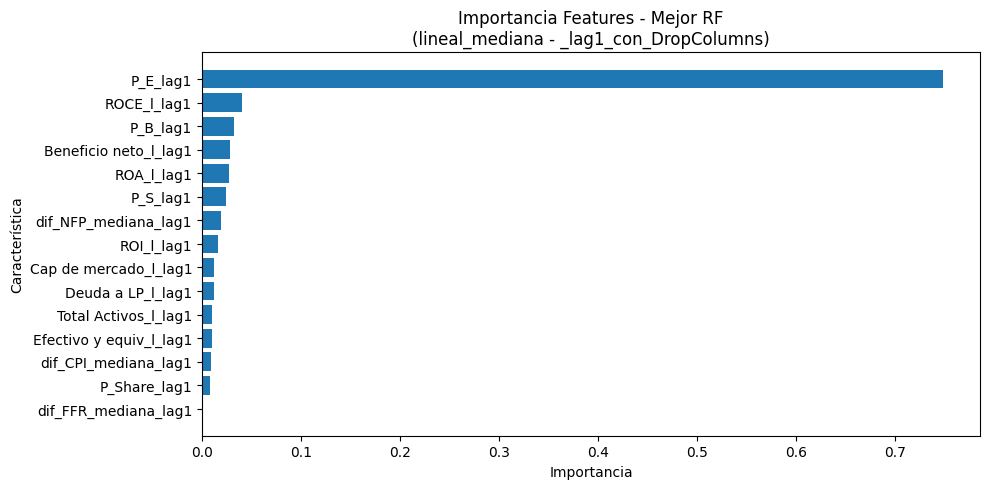

  Mejor XGB para lineal_mediana: RMSE = 32.9580
    Generando importancia de features para Mejor XGB de lineal_mediana...


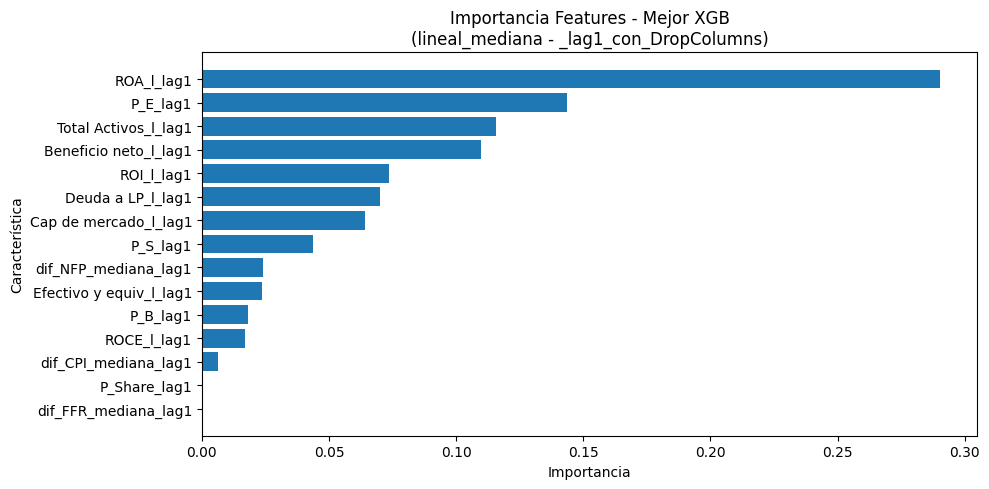

  Mejor LGBM para lineal_mediana: RMSE = 27.0549
    Generando importancia de features para Mejor LGBM de lineal_mediana...


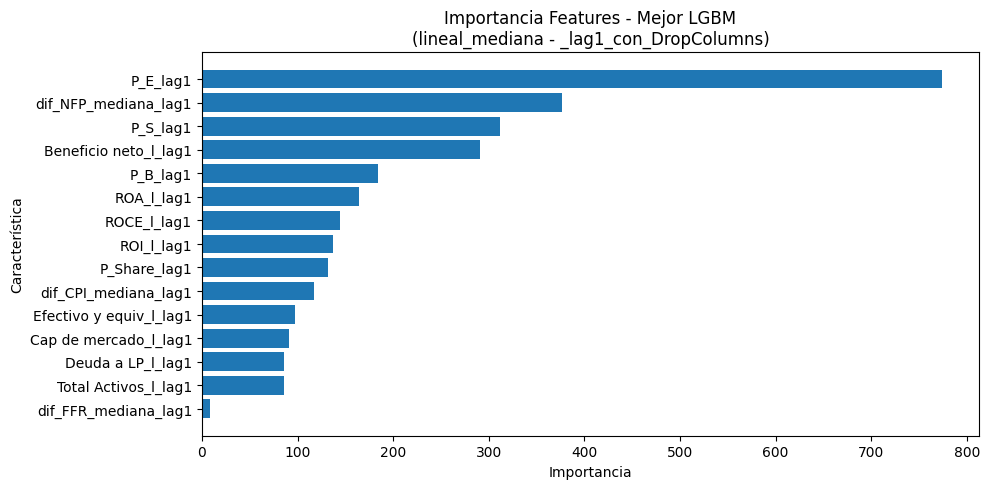

  Mejor CB para lineal_mediana: RMSE = 19.8914
    Generando importancia de features para Mejor CB de lineal_mediana...


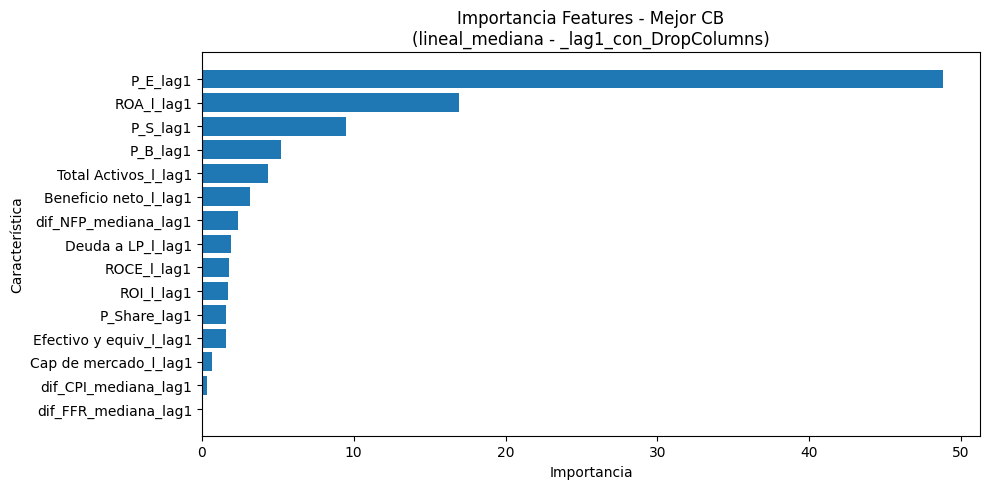


Paquete para 'lineal_mediana' guardado como: paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: spline_mediana ---
  Mejor RF para spline_mediana: RMSE = 19.3975
    Generando importancia de features para Mejor RF de spline_mediana...


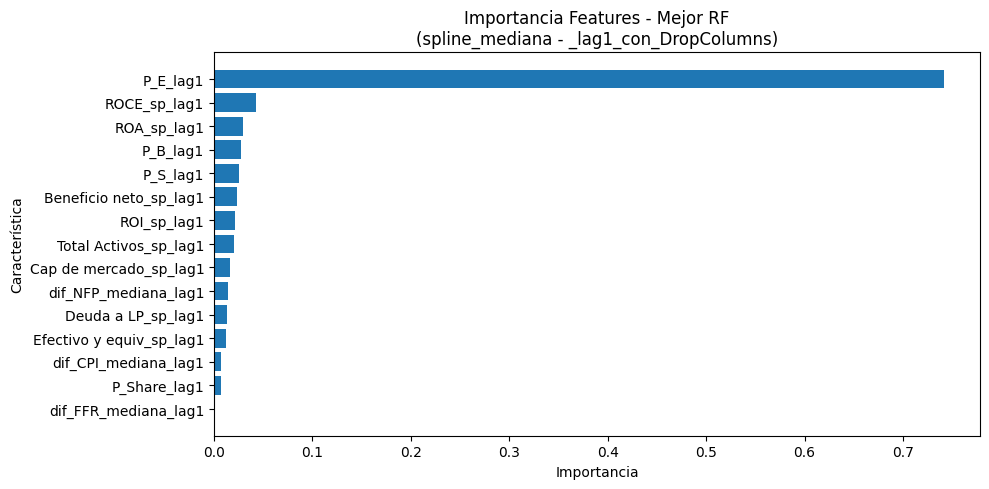

  Mejor XGB para spline_mediana: RMSE = 33.3798
    Generando importancia de features para Mejor XGB de spline_mediana...


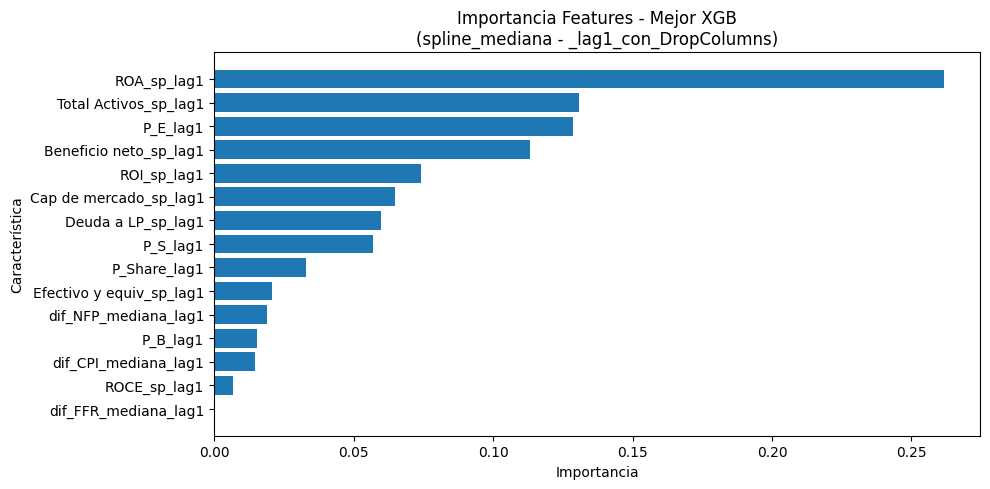

  Mejor LGBM para spline_mediana: RMSE = 25.7415
    Generando importancia de features para Mejor LGBM de spline_mediana...


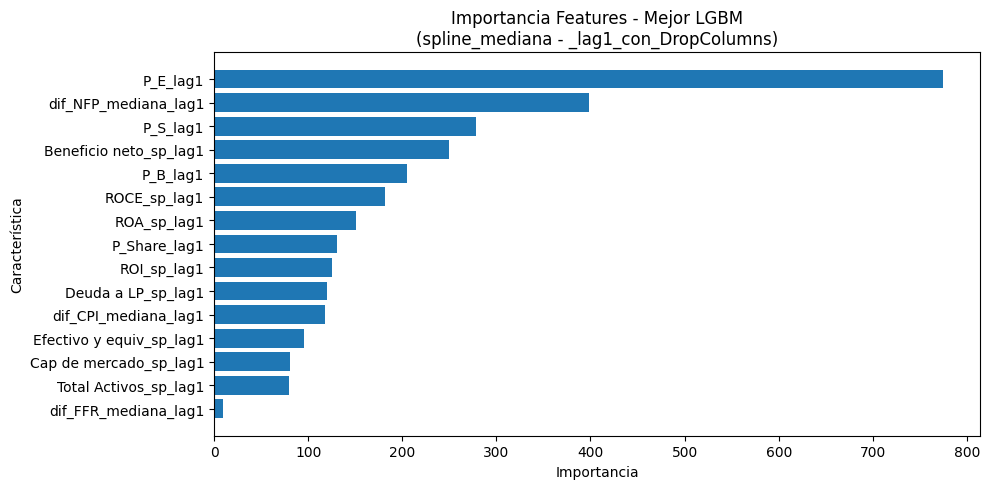

  Mejor CB para spline_mediana: RMSE = 20.8745
    Generando importancia de features para Mejor CB de spline_mediana...


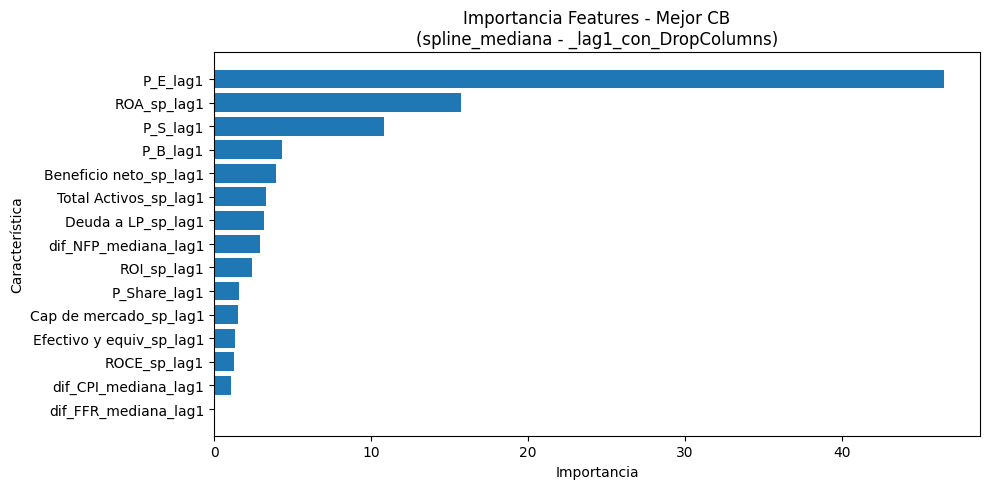


Paquete para 'spline_mediana' guardado como: paquete_mejores_por_tipo_spline_mediana__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: lineal_promedio ---
  Mejor RF para lineal_promedio: RMSE = 20.0183
    Generando importancia de features para Mejor RF de lineal_promedio...


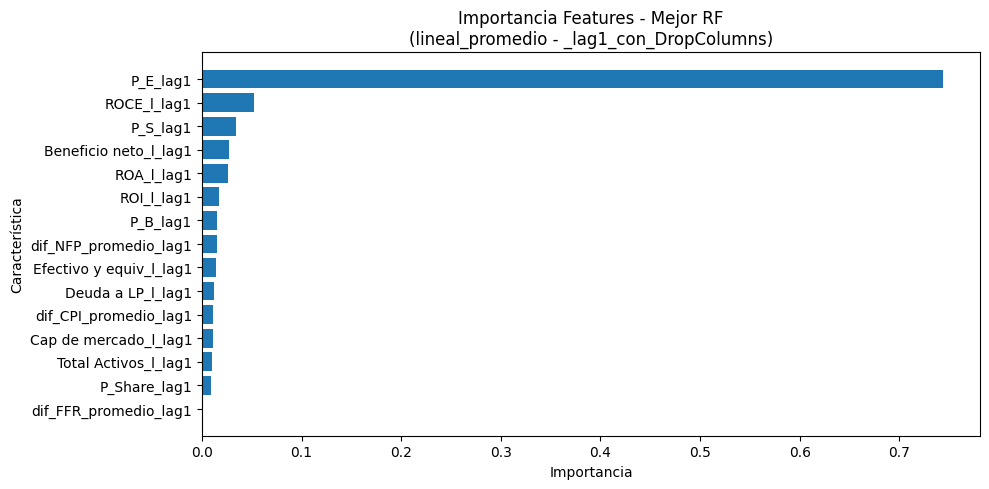

  Mejor XGB para lineal_promedio: RMSE = 32.9580
    Generando importancia de features para Mejor XGB de lineal_promedio...


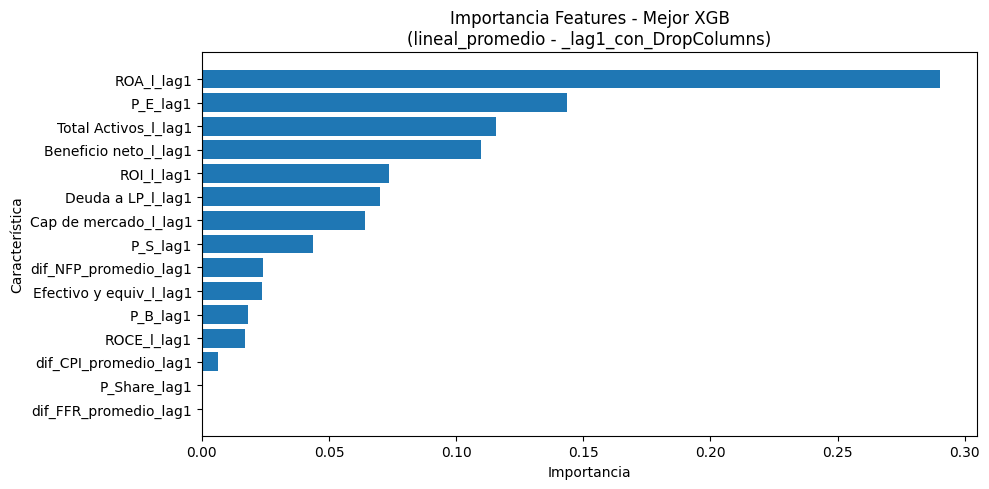

  Mejor LGBM para lineal_promedio: RMSE = 27.2850
    Generando importancia de features para Mejor LGBM de lineal_promedio...


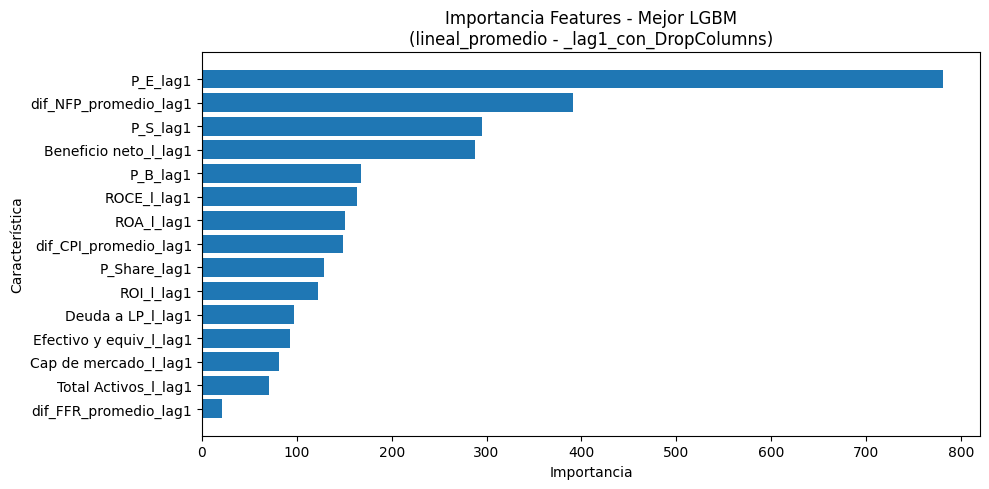

  Mejor CB para lineal_promedio: RMSE = 17.8656
    Generando importancia de features para Mejor CB de lineal_promedio...


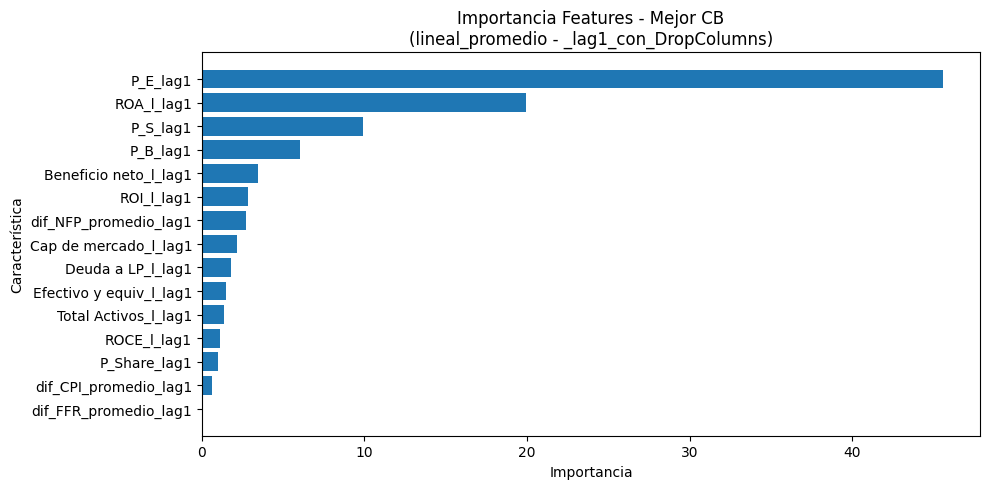


Paquete para 'lineal_promedio' guardado como: paquete_mejores_por_tipo_lineal_promedio__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: spline_promedio ---
  Mejor RF para spline_promedio: RMSE = 19.0946
    Generando importancia de features para Mejor RF de spline_promedio...


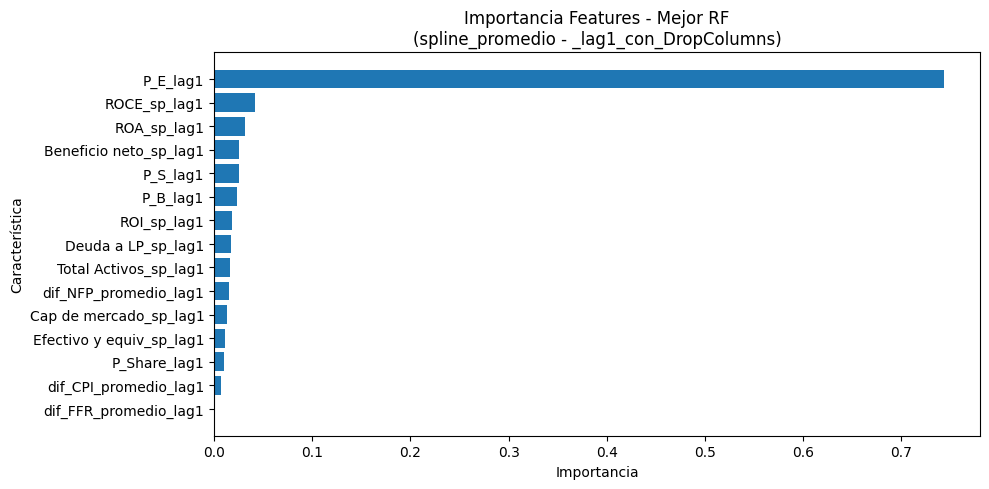

  Mejor XGB para spline_promedio: RMSE = 33.2493
    Generando importancia de features para Mejor XGB de spline_promedio...


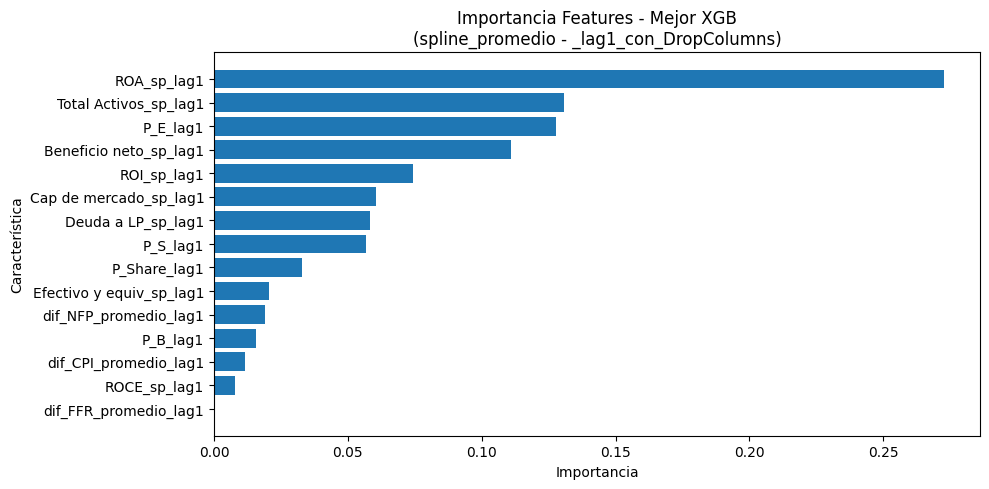

  Mejor LGBM para spline_promedio: RMSE = 25.5767
    Generando importancia de features para Mejor LGBM de spline_promedio...


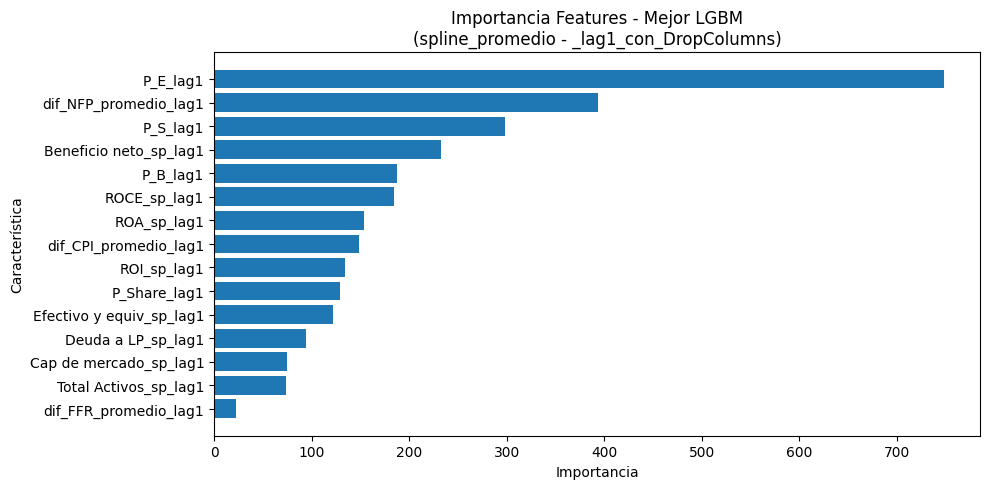

  Mejor CB para spline_promedio: RMSE = 20.6501
    Generando importancia de features para Mejor CB de spline_promedio...


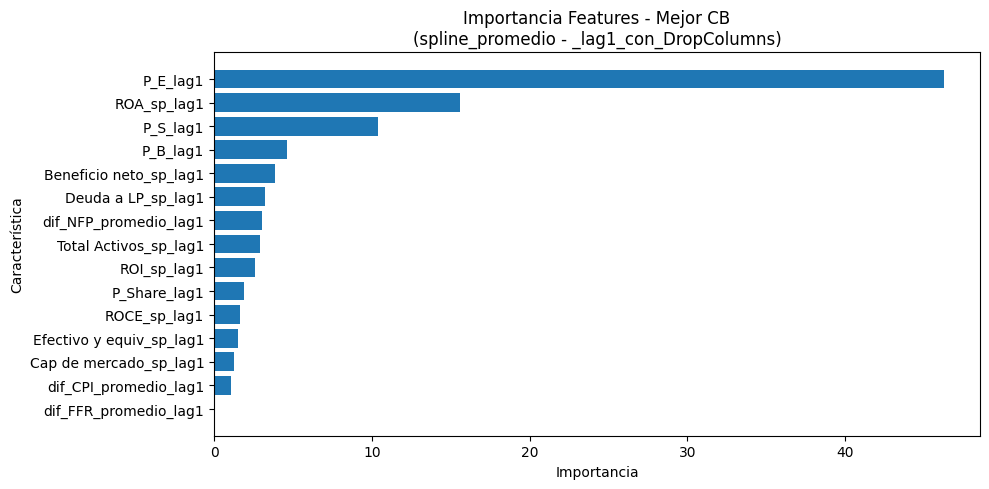


Paquete para 'spline_promedio' guardado como: paquete_mejores_por_tipo_spline_promedio__lag1_con_DropColumns.joblib

TABLA RESUMEN DE LOS MEJORES MODELOS POR TIPO
Metodo_Features            Lag_Config  Log_Transform Modelo_Tipo_Base    RMSE    MAE      R2  n_features_modelo                                                                                          Best_Params
 lineal_mediana _lag1_con_DropColumns          False               CB 19.8914 4.0517  0.6062                 15 {'model__depth': 5, 'model__iterations': 100, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.05}
 lineal_mediana _lag1_con_DropColumns          False               RF 19.9946 3.4664  0.6021                 15                                                                                                 None
 lineal_mediana _lag1_con_DropColumns          False             LGBM 27.0549 4.5554  0.2715                 15                                                                                      

In [30]:
# ================================================================================
# BLOQUE DE EXPERIMENTOS (CON DropColumns en Pipeline, PLOT FEATURE IMPORTANCE para Mejores por Tipo, GUARDAR PAQUETES)
# ================================================================================
results_accumulator = [] 
start_time_total_experiments = time.time()
use_log_transform_experiment = False
test_size_ratio_experiment = 0.20
LAG_SUFFIX_TO_USE = '_lag1' 

if 'dfs_shifted' not in locals() or not isinstance(dfs_shifted, dict) or not dfs_shifted:
    raise NameError("El diccionario 'dfs_shifted' no está definido o está vacío.")

for metodo_features, df_original_with_lags_and_ids in dfs_shifted.items():
    start_time_metodo = time.time()
    lag_config_display = f"{LAG_SUFFIX_TO_USE}_con_DropColumns" 

    print("\n" + "="*80)
    print(f"Procesando Método: {metodo_features} {'(CON Log Transform)' if use_log_transform_experiment else '(SIN Log Transform)'} (Lags: {LAG_SUFFIX_TO_USE}, con DropColumns)")
    print("="*80 + "\n")

    if df_original_with_lags_and_ids.empty: continue
    df_current_method_processed = df_original_with_lags_and_ids.copy()
    if 'time_step' not in df_current_method_processed.columns:
        df_current_method_processed.sort_values(['Empresa', 'Fecha'], inplace=True)
        df_current_method_processed['time_step'] = df_current_method_processed.groupby('Empresa').cumcount()

    predictor_cols_for_pipeline_input = sorted([
        c for c in df_current_method_processed.columns 
        if c.endswith(LAG_SUFFIX_TO_USE) and c not in ['Empresa', 'Fecha', 'time_step', 'P_E']
    ])
    if not predictor_cols_for_pipeline_input: continue
    columnas_base_que_generaron_lags = sorted(list(set(re.sub(r'_lag\d+$', '', lag_col) for lag_col in predictor_cols_for_pipeline_input)))
    
    all_relevant_cols_for_df = ['Empresa', 'Fecha', 'time_step', 'P_E'] + predictor_cols_for_pipeline_input
    final_cols_for_df_model_construction = sorted(list(set(c for c in all_relevant_cols_for_df if c in df_current_method_processed.columns)))
    essential_cols_check = ['Empresa', 'Fecha', 'time_step', 'P_E']
    if not all(ec in final_cols_for_df_model_construction for ec in essential_cols_check): continue
    df_model_for_splitting = df_current_method_processed[final_cols_for_df_model_construction].copy()

    n_total_empresas = df_model_for_splitting['Empresa'].nunique()
    n_empresas_test = 0
    if n_total_empresas > 1:
        n_empresas_test = max(1, int(round(n_total_empresas * test_size_ratio_experiment)))
        if n_total_empresas - n_empresas_test < 1 : n_empresas_test = n_total_empresas - 1
    X_train_with_ids, y_train_original, X_test_with_ids, y_test_original = train_test_split_by_empresa(df_model_for_splitting, n_empresas_test)
    if X_train_with_ids is None or X_train_with_ids.empty: continue
    
    y_train_transformed_target = y_train_original.copy()
    if use_log_transform_experiment:
        y_numeric = pd.to_numeric(y_train_original, errors='coerce')
        median_y_train = y_numeric.median() if not y_numeric.isnull().all() else 0.0
        y_numeric = y_numeric.fillna(median_y_train); y_numeric.loc[y_numeric < 0] = 0
        y_train_transformed_target = np.log1p(y_numeric)
        if y_train_transformed_target.isnull().any():
             median_y_transformed = y_train_transformed_target.median() if not y_train_transformed_target.isnull().all() else 0.0
             y_train_transformed_target = y_train_transformed_target.fillna(median_y_transformed)

    if not X_train_with_ids.index.equals(y_train_transformed_target.index):
        common_idx_train = X_train_with_ids.index.intersection(y_train_transformed_target.index)
        X_train_with_ids = X_train_with_ids.loc[common_idx_train]
        y_train_transformed_target = y_train_transformed_target.loc[common_idx_train]
        if X_train_with_ids.empty : continue

    X_train_s_with_ids, y_train_s_transformed = sort_by_timestep(X_train_with_ids, y_train_transformed_target)
    X_test_s_with_ids, y_test_s_original = pd.DataFrame(), pd.Series(dtype=float)
    if X_test_with_ids is not None and not X_test_with_ids.empty:
        X_test_s_with_ids, y_test_s_original = sort_by_timestep(X_test_with_ids, y_test_original)

    param_grid_rf   = {'model__max_depth':[10, 20, None],'model__min_samples_split':[5, 10],'model__n_estimators':[100, 200]}
    param_grid_xgb  = {'model__n_estimators':[100, 200],'model__max_depth':[3, 5, 7],'model__learning_rate':[0.1, 0.05]}
    param_grid_lgbm = {'model__n_estimators':[100, 200],'model__learning_rate':[0.1, 0.05],'model__max_depth':[3, 5, 7],'model__num_leaves':[15, 31]}
    param_grid_cb   = {'model__iterations':[100, 200],'model__learning_rate':[0.1, 0.05],'model__depth':[3, 5, 7],'model__l2_leaf_reg':[1, 3]}
    scenarios = {
        'RF_Simple':  {'model': RandomForestRegressor(random_state=42, n_jobs=-1), 'hp': False, 'vt': False, 'grid': param_grid_rf},
        'RF_HP':      {'model': RandomForestRegressor(random_state=42, n_jobs=-1), 'hp': True,  'vt': False, 'grid': param_grid_rf},
        'XGB_Simple': {'model': XGBRegressor(random_state=42, n_jobs=-1), 'hp': False, 'vt': False, 'grid': param_grid_xgb},
        'XGB_HP':     {'model': XGBRegressor(random_state=42, n_jobs=-1), 'hp': True,  'vt': False, 'grid': param_grid_xgb},
        'LGBM_Simple':{'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1), 'hp': False, 'vt': False, 'grid': param_grid_lgbm},
        'LGBM_HP':    {'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1), 'hp': True,  'vt': False, 'grid': param_grid_lgbm},
        'CB_Simple':  {'model': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False), 'hp': False, 'vt': False, 'grid': param_grid_cb},
        'CB_HP':      {'model': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False), 'hp': True,  'vt': False, 'grid': param_grid_cb},
    }

    for escenario_nombre, escenario_cfg in scenarios.items():
        tiempo_esc_inicio = time.time()
        current_base_model = escenario_cfg['model']; perform_hp_search = escenario_cfg['hp']; use_temporal_cv_in_scenario = escenario_cfg.get('vt', False)
        X_fit_data_pipeline = X_train_s_with_ids if use_temporal_cv_in_scenario else X_train_with_ids
        y_fit_data_pipeline = y_train_s_transformed if use_temporal_cv_in_scenario else y_train_transformed_target
        X_eval_data_pipeline = X_test_s_with_ids if use_temporal_cv_in_scenario else X_test_with_ids
        y_eval_data_original_final = y_test_s_original if use_temporal_cv_in_scenario else y_test_original
        if X_fit_data_pipeline.empty or y_fit_data_pipeline.empty:
            results_accumulator.append({'Modelo': escenario_nombre.split('_')[0], 'Validacion_Temp': use_temporal_cv_in_scenario,
                'Busqueda_HP': perform_hp_search, 'Config_Key': metodo_features, 'Metodo': metodo_features,
                'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 'RMSE': np.nan, 'MAE': np.nan, 
                'R2': np.nan, 'Best_Params': None, 'pipeline': 'Error: Datos vacíos', 
                'columnas_base_usadas': columnas_base_que_generaron_lags, 
                'n_features_modelo': len(predictor_cols_after_drop), 
                'features_usadas_por_modelo': [], 'Error': 'Datos vacíos'})
            continue
        cols_to_drop_in_pipeline = [col for col in ['Empresa', 'Fecha', 'time_step'] if col in X_fit_data_pipeline.columns]
        pipeline_obj_for_training = Pipeline([('drop_ids', DropColumns(columns=cols_to_drop_in_pipeline)), ('model', current_base_model)])
        model_actual_features_for_plot = [col for col in X_fit_data_pipeline.columns if col not in cols_to_drop_in_pipeline]
        final_fitted_pipeline, hp_best_params_found, error_msg_escenario = None, None, None
        try:
            if perform_hp_search:
                cv_strategy_obj, cv_fit_params_dict, can_perform_cv = None, {}, True
                n_groups_for_cv = X_fit_data_pipeline['Empresa'].nunique() if use_temporal_cv_in_scenario and 'Empresa' in X_fit_data_pipeline.columns else 0
                if use_temporal_cv_in_scenario and n_groups_for_cv >= 2:
                    groups_for_gkf = X_fit_data_pipeline['Empresa']; n_splits_gkf = min(3, n_groups_for_cv); n_splits_gkf = max(2, n_splits_gkf)
                    if len(X_fit_data_pipeline) < n_splits_gkf : can_perform_cv = False
                    else: cv_strategy_obj = GroupKFold(n_splits=n_splits_gkf); cv_fit_params_dict = {'groups': groups_for_gkf}
                elif len(X_fit_data_pipeline) >= 2:
                    n_samples_kf = len(X_fit_data_pipeline); kfold_splits_val = min(3, n_samples_kf); kfold_splits_val = max(2, kfold_splits_val)
                    if n_samples_kf < kfold_splits_val : can_perform_cv = False
                    else: cv_strategy_obj = KFold(n_splits=kfold_splits_val, shuffle=True, random_state=42)
                else: can_perform_cv = False
                if not can_perform_cv or cv_strategy_obj is None: perform_hp_search = False
                if perform_hp_search:
                    gs = GridSearchCV(pipeline_obj_for_training, escenario_cfg['grid'], scoring=rmse_scorer, cv=cv_strategy_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                    gs.fit(X_fit_data_pipeline, y_fit_data_pipeline, **cv_fit_params_dict)
                    final_fitted_pipeline, hp_best_params_found = gs.best_estimator_, gs.best_params_
            if not perform_hp_search or final_fitted_pipeline is None:
                pipeline_obj_for_training.fit(X_fit_data_pipeline, y_fit_data_pipeline)
                final_fitted_pipeline = pipeline_obj_for_training; hp_best_params_found = None
        except Exception as e: error_msg_escenario = str(e)
        eval_metrics_dict, n_features_in_final_model_attr = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}, "N/A"
        if final_fitted_pipeline:
            try:
                actual_estimator = final_fitted_pipeline.steps[-1][1]
                n_features_in_final_model_attr = getattr(actual_estimator, 'n_features_in_', "N/A")
                if not X_eval_data_pipeline.empty and not y_eval_data_original_final.empty:
                    pred_transformed_eval = final_fitted_pipeline.predict(X_eval_data_pipeline)
                    pred_original_scale_eval = np.expm1(pred_transformed_eval) if use_log_transform_experiment else pred_transformed_eval
                    if use_log_transform_experiment: pred_original_scale_eval[~np.isfinite(pred_original_scale_eval)] = np.nan
                    eval_metrics_dict = evaluate_model(y_eval_data_original_final, pred_original_scale_eval)
                    print(f"    Métricas Test {escenario_nombre}: RMSE={eval_metrics_dict['RMSE']:.4f}, MAE={eval_metrics_dict['MAE']:.4f}, R2={eval_metrics_dict['R2']:.4f}")
                # NO PLOTEAMOS AQUÍ, LO HAREMOS AL FINAL PARA LOS MEJORES POR TIPO
            except Exception as e_eval: error_msg_escenario = (error_msg_escenario + f" | EvalError: {str(e_eval)}") if error_msg_escenario else f"EvalError: {str(e_eval)}"
        
        results_accumulator.append({
            'Modelo': escenario_nombre.split('_')[0], 'Validacion_Temp': use_temporal_cv_in_scenario and isinstance(cv_strategy_obj, GroupKFold),
            'Busqueda_HP': escenario_cfg['hp'] and perform_hp_search, 
            'Config_Key': metodo_features, 'Metodo': metodo_features, 
            'Lag_Config': lag_config_display, 
            'Log_Transform': use_log_transform_experiment, 
            'RMSE': eval_metrics_dict['RMSE'], 'MAE': eval_metrics_dict['MAE'], 'R2': eval_metrics_dict['R2'], 
            'Best_Params': hp_best_params_found, 
            'pipeline': final_fitted_pipeline, 
            'columnas_base_usadas': columnas_base_que_generaron_lags, 
            'n_features_modelo': n_features_in_final_model_attr, 
            'features_usadas_por_modelo': model_actual_features_for_plot, # Guardar las features que vio el estimador
            'Error': error_msg_escenario
        })
    print(f"\nTiempo total para Método: {metodo_features}: {time.time() - start_time_metodo:.2f}s")
print(f"\n\nTiempo total de ejecución de todos los experimentos: {(time.time() - start_time_total_experiments)/60:.2f} minutos")

# ================================================================================
# CREAR TABLA DE RESULTADOS GENERAL, GUARDAR PAQUETES Y PLOTEAR MEJORES POR TIPO
# ================================================================================
if results_accumulator:
    df_results_all_experiments = pd.DataFrame(results_accumulator)
    print("\n" + "="*80 + "\n--- Resultados Finales Globales ---\n" + f"Total resultados: {len(df_results_all_experiments)}\n")
    cols_to_display_summary = ['Metodo', 'Modelo', 'Busqueda_HP', 'RMSE', 'MAE', 'R2', 'n_features_modelo', 'Lag_Config', 'Error', 'Best_Params'] # Quitado 'features_usadas_por_modelo' para brevedad
    final_cols_to_display_summary = [col for col in cols_to_display_summary if col in df_results_all_experiments.columns]
    with pd.option_context('display.max_rows', 200, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
        print(df_results_all_experiments.sort_values(by=['Metodo','RMSE'], ascending=[True,True])[final_cols_to_display_summary].to_string(index=False))

    lista_info_mejores_por_tipo_global = []
    for metodo_actual_features_key in df_results_all_experiments['Metodo'].unique(): 
        print("\n" + "="*70 + f"\n--- Preparando paquete y plots para Método: {metodo_actual_features_key} ---")
        df_resultados_metodo_actual = df_results_all_experiments[
            (df_results_all_experiments['Metodo'] == metodo_actual_features_key) &
            (df_results_all_experiments['RMSE'].notna()) &
            (df_results_all_experiments['pipeline'].notna()) & 
            (df_results_all_experiments['Error'].isna()) &
            (df_results_all_experiments['pipeline'].apply(lambda x: not (isinstance(x, str) and x.startswith('Error:')))) & # Asegurar que pipeline no sea string de error
            (df_results_all_experiments['features_usadas_por_modelo'].apply(lambda x: isinstance(x, list) and len(x) > 0)) # Asegurar que hay features
        ].copy()

        if df_resultados_metodo_actual.empty: 
            print(f"No hay resultados válidos con features para el método '{metodo_actual_features_key}' para crear paquete o plotear.")
            continue

        mejores_modelos_info_para_paquete = {}
        modelos_base_a_considerar = ['RF', 'XGB', 'LGBM', 'CB']
        
        metadata_ref_row = df_resultados_metodo_actual.iloc[0]
        log_transform_paquete_actual = metadata_ref_row.get('Log_Transform', True)
        columnas_base_paquete_actual = metadata_ref_row.get('columnas_base_usadas', []) 
        lag_config_paquete_actual = metadata_ref_row.get('Lag_Config', 'desconocida')
        
        for tipo_modelo_base in modelos_base_a_considerar:
            df_tipo_especifico = df_resultados_metodo_actual[df_resultados_metodo_actual['Modelo'] == tipo_modelo_base]
            if not df_tipo_especifico.empty:
                mejor_fila_tipo_actual = df_tipo_especifico.sort_values(by='RMSE', ascending=True).iloc[0]
                
                pipeline_obj_actual = mejor_fila_tipo_actual['pipeline']
                features_usadas_actual = mejor_fila_tipo_actual['features_usadas_por_modelo']

                mejores_modelos_info_para_paquete[tipo_modelo_base] = {
                    'pipeline_object': pipeline_obj_actual,
                    'RMSE': mejor_fila_tipo_actual['RMSE'], 'MAE': mejor_fila_tipo_actual['MAE'],
                    'R2': mejor_fila_tipo_actual['R2'], 'Best_Params': mejor_fila_tipo_actual['Best_Params'],
                    'n_features_modelo': mejor_fila_tipo_actual['n_features_modelo'],
                    'features_usadas_por_modelo': features_usadas_actual, 
                    'Escenario_Validacion_Temp': mejor_fila_tipo_actual['Validacion_Temp'],
                    'Escenario_Busqueda_HP': mejor_fila_tipo_actual['Busqueda_HP']}
                
                print(f"  Mejor {tipo_modelo_base} para {metodo_actual_features_key}: RMSE = {mejor_fila_tipo_actual['RMSE']:.4f}")

                # --- PLOT FEATURE IMPORTANCE PARA ESTE MEJOR MODELO POR TIPO ---
                titulo_plot_tipo = (
                    f"Importancia Features - Mejor {tipo_modelo_base}\n"
                    f"({metodo_actual_features_key} - {lag_config_paquete_actual})"
                )
                print(f"    Generando importancia de features para Mejor {tipo_modelo_base} de {metodo_actual_features_key}...")
                plot_feature_importances(
                    pipeline_obj_actual, # El pipeline completo (DropColumns + modelo)
                    feature_names=features_usadas_actual, # Las features que vio el estimador final
                    title=titulo_plot_tipo
                )
                # --- FIN PLOT ---

                info_para_tabla_resumen = {
                    'Metodo_Features': metodo_actual_features_key, 
                    'Lag_Config': lag_config_paquete_actual,
                    'Log_Transform': log_transform_paquete_actual, 
                    'Modelo_Tipo_Base': tipo_modelo_base,
                    'RMSE': mejor_fila_tipo_actual['RMSE'], 'MAE': mejor_fila_tipo_actual['MAE'],
                    'R2': mejor_fila_tipo_actual['R2'], 'n_features_modelo': mejor_fila_tipo_actual['n_features_modelo'],
                    'Best_Params': mejor_fila_tipo_actual['Best_Params']}
                lista_info_mejores_por_tipo_global.append(info_para_tabla_resumen)
            else: 
                mejores_modelos_info_para_paquete[tipo_modelo_base] = None 

        if any(mejores_modelos_info_para_paquete.values()):
            paquete_final_a_guardar = {
                'metodo_features': metodo_actual_features_key, 
                'lag_config_usada': lag_config_paquete_actual,
                'log_transform_target': log_transform_paquete_actual,
                'columnas_base_para_lags': columnas_base_paquete_actual, 
                'mejores_modelos_info_por_tipo': mejores_modelos_info_para_paquete
            }
            nombre_archivo_paquete_final = f"paquete_mejores_por_tipo_{metodo_actual_features_key.replace(' ', '_')}_{lag_config_paquete_actual}.joblib"
            try:
                joblib.dump(paquete_final_a_guardar, nombre_archivo_paquete_final)
                print(f"\nPaquete para '{metodo_actual_features_key}' guardado como: {nombre_archivo_paquete_final}")
            except Exception as e_dump_final_package: print(f"\nERROR al guardar paquete para '{metodo_actual_features_key}': {e_dump_final_package}")
    
    if lista_info_mejores_por_tipo_global:
        df_mejores_por_tipo_global = pd.DataFrame(lista_info_mejores_por_tipo_global)
        print("\n" + "="*80 + "\nTABLA RESUMEN DE LOS MEJORES MODELOS POR TIPO" + "\n" + "="*80)
        with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
            cols_resumen_mejores = ['Metodo_Features', 'Lag_Config', 'Log_Transform', 'Modelo_Tipo_Base', 'RMSE', 'MAE', 'R2', 'n_features_modelo', 'Best_Params']
            cols_resumen_existentes = [col for col in cols_resumen_mejores if col in df_mejores_por_tipo_global.columns]
            print(df_mejores_por_tipo_global.sort_values(by=['Metodo_Features', 'RMSE'], ascending=[True, True])[cols_resumen_existentes].to_string(index=False))
else: 
    print("\nNo se generaron resultados en los experimentos.")

In [31]:
df_mejores_por_tipo_global.sort_values(by=["R2"], ascending=False)

,Metodo_Features,Lag_Config,Log_Transform,Modelo_Tipo_Base,RMSE,MAE,R2,n_features_modelo,Best_Params
11,lineal_promedio,_lag1_con_DropColumns,False,CB,17.865596,4.109345,0.682352,15,"{'model__depth': 7, 'model__iterations': 100, ..."
12,spline_promedio,_lag1_con_DropColumns,False,RF,19.094595,3.372595,0.637146,15,None
4,spline_mediana,_lag1_con_DropColumns,False,RF,19.397481,3.414960,0.625543,15,None
3,lineal_mediana,_lag1_con_DropColumns,False,CB,19.891410,4.051653,0.606230,15,"{'model__depth': 5, 'model__iterations': 100, ..."
0,lineal_mediana,_lag1_con_DropColumns,False,RF,19.994563,3.466381,0.602135,15,None
8,lineal_promedio,_lag1_con_DropColumns,False,RF,20.018260,3.418518,0.601192,15,None
15,spline_promedio,_lag1_con_DropColumns,False,CB,20.650136,3.893487,0.575618,15,None
7,spline_mediana,_lag1_con_DropColumns,False,CB,20.874541,3.890308,0.566344,15,None
14,spline_promedio,_lag1_con_DropColumns,False,LGBM,25.576704,4.547469,0.348971,15,None
6,spline_mediana,_lag1_con_DropColumns,False,LGBM,25.741500,4.532889,0.340554,15,None


In [32]:
# Celda: BLOQUE DE PREDICCIÓN PARA DLOCAL (MODELOS INDIVIDUALES - GRÁFICOS Y MÉTRICAS)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import joblib
import os
import re # Para la lógica de extracción de lags

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# --- Definiciones de Clases y Funciones Auxiliares ---
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None): self.columns = columns if columns is not None else []
    def fit(self, X, y=None): return self
    def transform(self, X):
        if not isinstance(X, pd.DataFrame): return X
        return X.copy().drop(columns=self.columns, errors='ignore')

def rmse(y_true, y_pred):
    y_true_np, y_pred_np = np.asarray(y_true), np.asarray(y_pred)
    mask = np.isfinite(y_true_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_true_np, y_pred_np = y_true_np[mask], y_pred_np[mask]
    if len(y_true_np) == 0: return np.nan
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

def evaluate_model(y_test, y_pred):
    y_test_np, y_pred_np = np.asarray(y_test), np.asarray(y_pred)
    mask = np.isfinite(y_test_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_test_np, y_pred_np = y_test_np[mask], y_pred_np[mask]
    if len(y_test_np) == 0: return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
    mae = mean_absolute_error(y_test_np, y_pred_np); rmse_val = rmse(y_test_np, y_pred_np)
    r2 = np.nan
    if len(y_test_np) > 1 and np.var(y_test_np) > 1e-9:
        try: r2 = r2_score(y_test_np, y_pred_np)
        except ValueError: pass
    elif len(y_test_np) > 0 and mean_squared_error(y_test_np, y_pred_np) < 1e-9: r2 = 1.0
    elif len(y_test_np) > 0: r2 = 0.0
    return {'RMSE': rmse_val, 'MAE': mae, 'R2': r2}

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

Cargando paquete de modelos desde: paquete_mejores_por_tipo_lineal_promedio__lag1_con_DropColumns.joblib
Paquete de modelos cargado exitosamente.
  Información del Paquete: Método=lineal_promedio, LagConfig=_lag1_con_DropColumns, LogT=True
    Columnas Base (usadas para generar lags): 15 ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a LP_l', 'Efectivo y equiv_l', 'P_B']...
    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.
Se generarán lags [1] para DLocal.

Preparando datos de DLocal (Método: lineal_promedio, Lags: [1])
Generando lags para DLocal para las features: ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a LP_l', 'Efectivo y equiv_l', 'P_B', 'P_E', 'P_S', 'P_Share', 'ROA_l', 'ROCE_l', 'ROI_l', 'Total Activos_l', 'dif_CPI_promedio', 'dif_FFR_promedio', 'dif_NFP_promedio']
Se generaron 15 columnas de lag para DLocal: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
    ¡Confirm

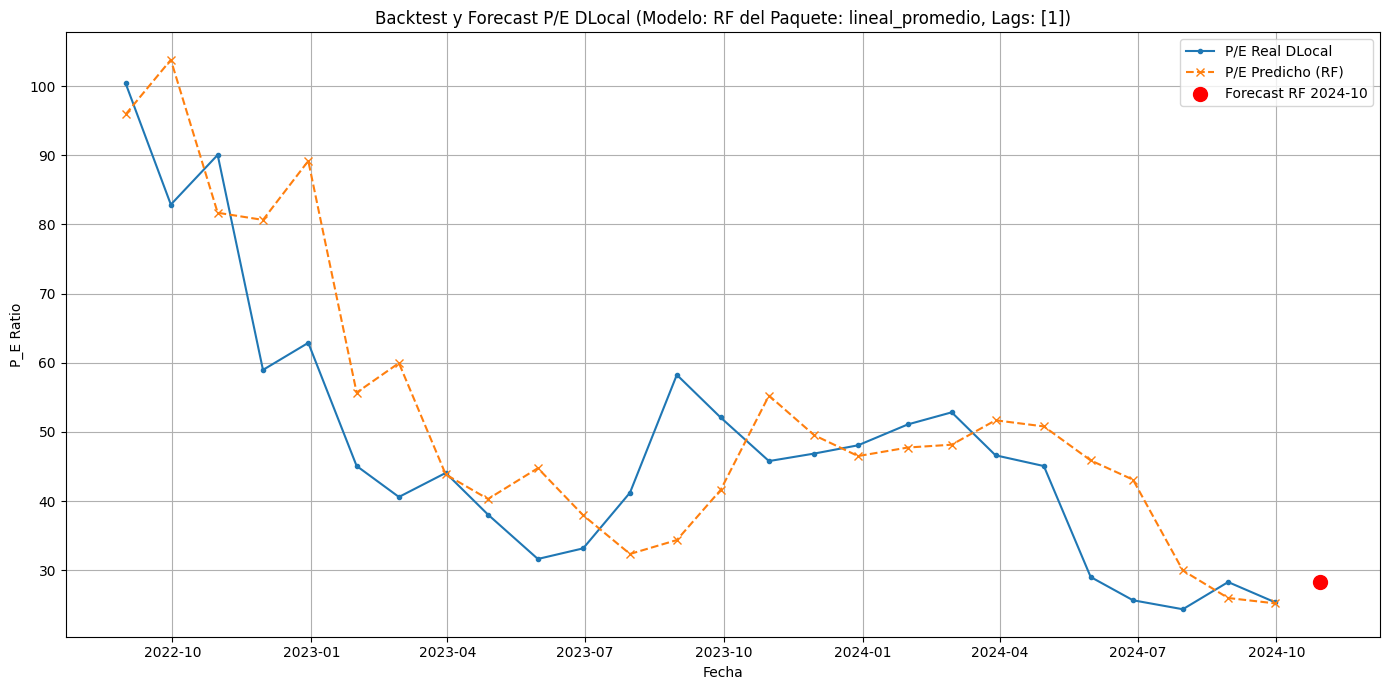


--- Procesando Modelo Tipo: XGB ---
  Features esperadas por XGB (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (XGB): RMSE=14.8839, MAE=11.2432, R2=0.3792


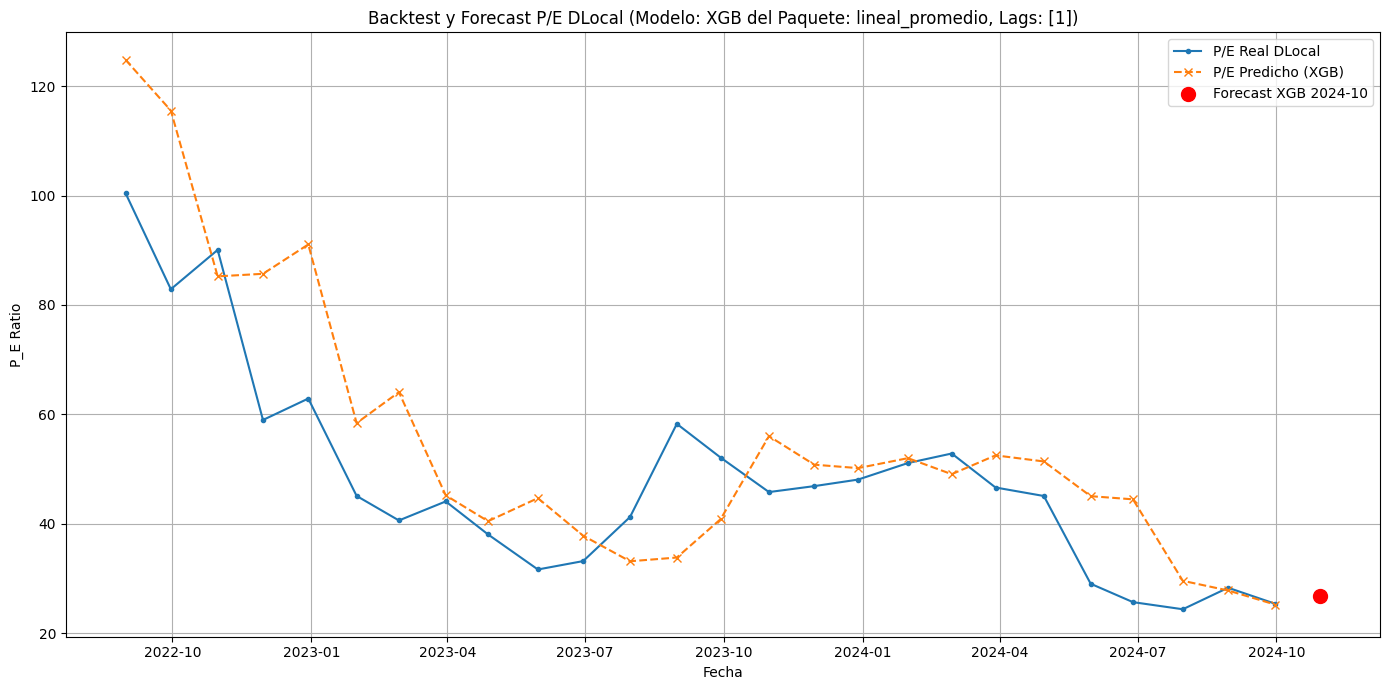


--- Procesando Modelo Tipo: LGBM ---
  Features esperadas por LGBM (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (LGBM): RMSE=14.1987, MAE=10.7969, R2=0.4351


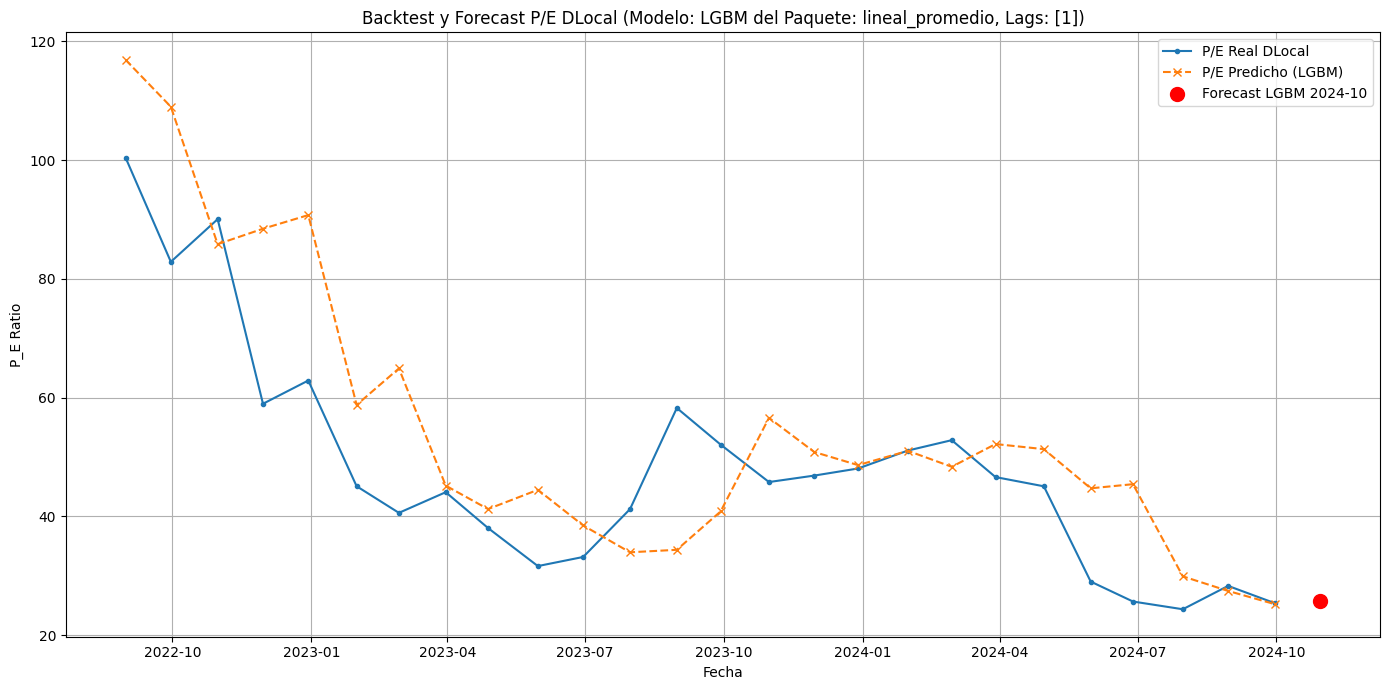


--- Procesando Modelo Tipo: CB ---
  Features esperadas por CB (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (CB): RMSE=13.0215, MAE=9.7929, R2=0.5249


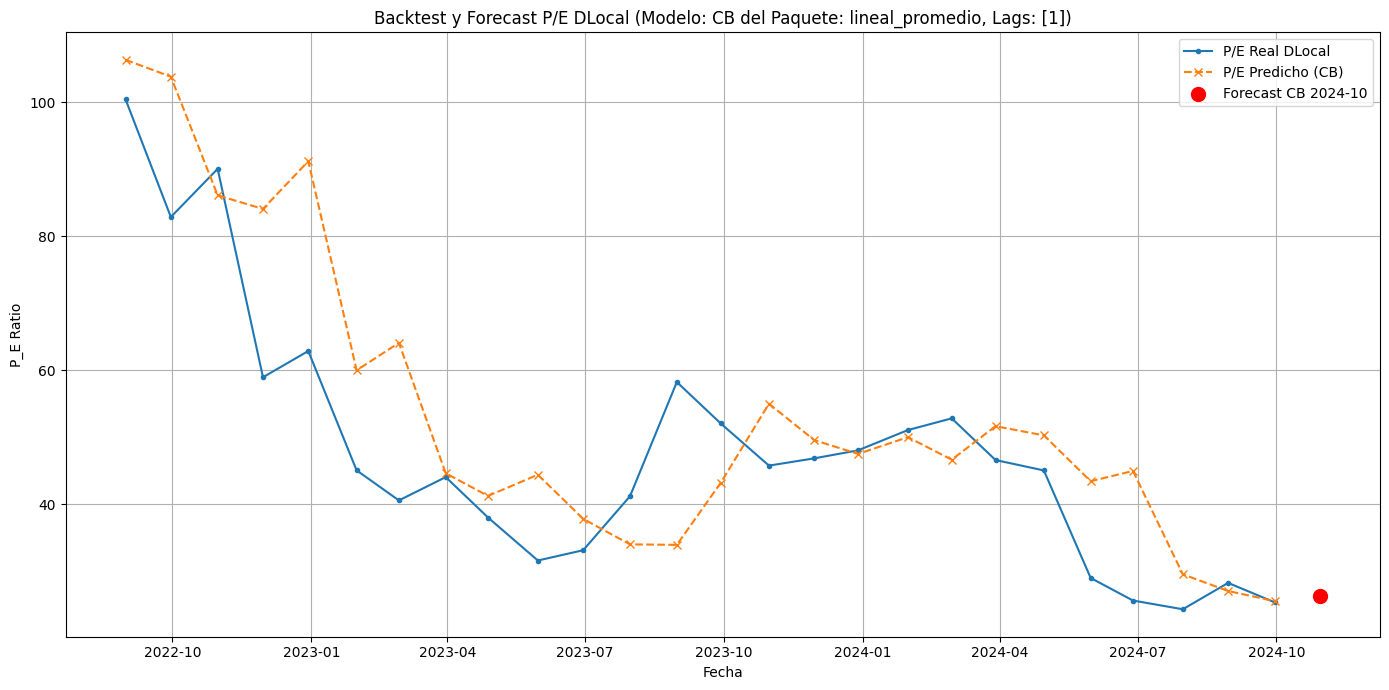


Resumen de Métricas Individuales de los Modelos en el Backtest de DLocal
Modelo_Tipo    RMSE     MAE     R2
         RF 12.3326  9.6277 0.5738
         CB 13.0215  9.7929 0.5249
       LGBM 14.1987 10.7969 0.4351
        XGB 14.8839 11.2432 0.3792

Proceso de predicción para DLocal completado.


In [36]:
# =====================================================================================
# BLOQUE DE PREDICCIÓN PARA DLOCAL (MODELOS INDIVIDUALES - GRÁFICOS Y MÉTRICAS)
# =====================================================================================

# --- 0. CONFIGURACIÓN Y CARGA DEL PAQUETE DEL MODELO ---
# ASUME: df_dlocal está cargado.
#        listas_columnas está definida (si es necesaria como fallback para columnas_base_paquete).
#        El paquete fue entrenado incluyendo P_E_lagN como feature si se desea usar aquí.

nombre_paquete_a_cargar = "paquete_mejores_por_tipo_lineal_promedio__lag1_con_DropColumns.joblib"

print(f"Cargando paquete de modelos desde: {nombre_paquete_a_cargar}")
model_package = None
try:
    ruta_paquete = os.path.join(os.getcwd(), nombre_paquete_a_cargar)
    if not os.path.exists(ruta_paquete):
        raise FileNotFoundError(f"El archivo del paquete '{ruta_paquete}' no existe.")
    model_package = joblib.load(ruta_paquete)
    print("Paquete de modelos cargado exitosamente.")

    required_keys = ['metodo_features', 'lag_config_usada', 'log_transform_target', 'mejores_modelos_info_por_tipo']
    if not isinstance(model_package, dict) or not all(key in model_package for key in required_keys):
        raise ValueError("El archivo cargado no es un paquete de modelos válido o le faltan claves esenciales.")

    metodo_features_paquete = model_package['metodo_features']
    lag_config_paquete = model_package['lag_config_usada'] 
    log_transform_paquete = model_package['log_transform_target']
    columnas_base_paquete = model_package.get('columnas_base_para_lags') # Esta clave debe existir en tu paquete
    mejores_modelos_info = model_package['mejores_modelos_info_por_tipo']

    if not columnas_base_paquete: # Fallback si no está en el paquete
        print("ADVERTENCIA: 'columnas_base_para_lags' no encontrada en el paquete. Intentando usar 'listas_columnas'.")
        if 'listas_columnas' in locals() and metodo_features_paquete in listas_columnas:
            columnas_base_paquete = listas_columnas[metodo_features_paquete]
            # Si P_E_lagN se usó y 'P_E' no está en listas_columnas[metodo_features_paquete], hay que añadirlo:
            # Esta lógica asume que si P_E_lagN es una feature, 'P_E' debe estar en las bases para generar ese lag.
            # El paquete idealmente ya tendría 'P_E' en 'columnas_base_para_lags' si P_E_lagN fue usado.
            # Si el paquete es de "solo lags de P/E", columnas_base_paquete debería ser ['P_E'].
            if 'P_E' not in columnas_base_paquete and any(f.startswith("P_E_lag") for f_dict in mejores_modelos_info.values() if f_dict and 'features_usadas_por_modelo' in f_dict for f in f_dict['features_usadas_por_modelo']):
                 if 'P_E' in df_dlocal.columns:
                    print("Añadiendo 'P_E' a columnas_base_paquete para generar su lag, basado en features de modelos.")
                    columnas_base_paquete.append('P_E')
                    columnas_base_paquete = sorted(list(set(columnas_base_paquete)))
        else: 
            raise ValueError("No se pudieron determinar las 'columnas_base_para_lags' ni del paquete ni de 'listas_columnas'.")
    
    print(f"  Información del Paquete: Método={metodo_features_paquete}, LagConfig={lag_config_paquete}, LogT={log_transform_paquete}")
    print(f"    Columnas Base (usadas para generar lags): {len(columnas_base_paquete)} {columnas_base_paquete[:5]}...")
    if 'P_E' in columnas_base_paquete:
        print("    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.")
    else:
        print("    ADVERTENCIA: 'P_E' NO está en columnas_base_paquete. NO se generará P_E_lagN como feature para DLocal, a menos que lag_config_paquete lo fuerce.")

except FileNotFoundError: raise FileNotFoundError(f"ERROR FATAL: No se encontró el archivo del paquete '{nombre_paquete_a_cargar}'.")
except Exception as e_load_pack: raise RuntimeError(f"Error fatal al cargar o procesar el paquete: {e_load_pack}")

if 'df_dlocal' not in locals() or not isinstance(df_dlocal, pd.DataFrame) or df_dlocal.empty:
     raise NameError("'df_dlocal' no definido o vacío.")

# Determinar qué lags generar para DLocal basado en lag_config_paquete
lags_a_generar_dlocal = []
temp_lag_str_cfg = str(lag_config_paquete).lower()
temp_lag_str_cfg = temp_lag_str_cfg.replace('pe_lags_', '').replace('_solo_pred', '').replace('lags_', '').replace('lag', '')
found_numbers_cfg = re.findall(r'\d+', temp_lag_str_cfg)
if found_numbers_cfg:
    lags_a_generar_dlocal = sorted(list(set(int(num) for num in found_numbers_cfg)))
if not lags_a_generar_dlocal: # Fallback
    for i in range(1, 7): 
        if f"lag{i}" in str(lag_config_paquete).lower() or f"_{i}" in str(lag_config_paquete): 
            lags_a_generar_dlocal.append(i)
    lags_a_generar_dlocal = sorted(list(set(lags_a_generar_dlocal)))
if not lags_a_generar_dlocal:
    raise ValueError(f"No se pudo determinar qué lags numéricos generar a partir de lag_config_paquete: '{lag_config_paquete}'")
print(f"Se generarán lags {lags_a_generar_dlocal} para DLocal.")


# --- 1. PREPARAR df_dlocal ---
print("\n" + "="*80 + f"\nPreparando datos de DLocal (Método: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})" + "\n" + "="*80)
df_dlocal_procesado_base = df_dlocal.copy()

# 1.1 Conversión Numérica
# Usar 'columnas_base_paquete' que ahora debería incluir 'P_E' si P_E_lagN es una feature.
cols_convertir_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
for col in cols_convertir_dlocal:
    if not pd.api.types.is_numeric_dtype(df_dlocal_procesado_base[col]):
        df_dlocal_procesado_base[col] = pd.to_numeric(df_dlocal_procesado_base[col], errors='coerce')

# 1.2 Imputación Pre-Lag
cols_imputar_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
if cols_imputar_dlocal:
    df_dlocal_procesado_base.sort_values(['Empresa', 'Fecha'], inplace=True)
    if df_dlocal_procesado_base['Empresa'].nunique() > 1:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base.groupby('Empresa')[cols_imputar_dlocal].ffill()
    else:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].ffill()
    df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].fillna(0)

# 1.3 Generar Lags
# 'features_para_generar_lags_dlocal' se basa en 'columnas_base_paquete'
features_para_generar_lags_dlocal = [c for c in columnas_base_paquete if c in df_dlocal_procesado_base.columns]
# Asegurar que P_E esté si se espera P_E_lagN y no está ya en features_para_generar_lags_dlocal
# (Esta lógica es un poco redundante si columnas_base_paquete ya es correcta)
if any(f"P_E_lag{lg}" in model_info_actual.get('features_usadas_por_modelo',[]) for lg in lags_a_generar_dlocal for model_info_actual in mejores_modelos_info.values() if model_info_actual) \
   and 'P_E' not in features_para_generar_lags_dlocal and 'P_E' in df_dlocal_procesado_base.columns:
    print("  Asegurando que 'P_E' se incluya para generar sus lags para DLocal.")
    features_para_generar_lags_dlocal.append('P_E')
    features_para_generar_lags_dlocal = sorted(list(set(features_para_generar_lags_dlocal)))


cols_necesarias_para_base_df = ['Empresa', 'Fecha']
if 'P_E' in df_dlocal_procesado_base.columns: cols_necesarias_para_base_df.append('P_E')
for f_lag in features_para_generar_lags_dlocal:
    if f_lag not in cols_necesarias_para_base_df: cols_necesarias_para_base_df.append(f_lag)

df_dlocal_con_todos_lags = df_dlocal_procesado_base[cols_necesarias_para_base_df].copy()
all_generated_lag_cols_dlocal = []

print(f"Generando lags para DLocal para las features: {features_para_generar_lags_dlocal}")
for lag_val in lags_a_generar_dlocal:
    for col_base_para_lag in features_para_generar_lags_dlocal:
        lag_col_name = f"{col_base_para_lag}_lag{lag_val}"
        df_dlocal_con_todos_lags[lag_col_name] = df_dlocal_con_todos_lags.groupby('Empresa')[col_base_para_lag].shift(lag_val)
        all_generated_lag_cols_dlocal.append(lag_col_name)
all_generated_lag_cols_dlocal = sorted(list(set(all_generated_lag_cols_dlocal)))
print(f"Se generaron {len(all_generated_lag_cols_dlocal)} columnas de lag para DLocal: {all_generated_lag_cols_dlocal[:5]}...")
# Confirmación de P_E_lagN
pe_lags_actually_generated = [col for col in all_generated_lag_cols_dlocal if col.startswith("P_E_lag")]
if pe_lags_actually_generated:
    print(f"    ¡Confirmado! Lags de P/E generados: {pe_lags_actually_generated}")
else:
    print("    ADVERTENCIA: NO se generaron lags de P/E para DLocal. Verifica 'columnas_base_paquete' y la lógica de generación de lags.")

# 1.4 Aplicar dropna
df_dlocal_final_features_con_ids = df_dlocal_con_todos_lags.dropna(subset=all_generated_lag_cols_dlocal).copy()
if df_dlocal_final_features_con_ids.empty: raise ValueError("DLocal vacío post lags y dropna.")
print(f"DataFrame DLocal procesado y listo (con IDs y lags): {df_dlocal_final_features_con_ids.shape}")

# --- 2. ITERAR, PREDECIR, EVALUAR INDIVIDUALMENTE Y GRAFICAR ---
print("\n" + "="*80 + "\nIterando sobre modelos por tipo para predicción, evaluación y graficación individual en DLocal" + "\n" + "="*80)
lista_metricas_individuales_dlocal = []

for tipo_modelo_actual, model_info_actual in mejores_modelos_info.items():
    print(f"\n--- Procesando Modelo Tipo: {tipo_modelo_actual} ---")

    if model_info_actual is None or 'pipeline_object' not in model_info_actual or model_info_actual['pipeline_object'] is None:
        print(f"  No hay un pipeline válido para '{tipo_modelo_actual}'. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    pipeline_cargado_actual = model_info_actual['pipeline_object']
    estimador_real_actual = pipeline_cargado_actual
    if hasattr(pipeline_cargado_actual, 'steps'): estimador_real_actual = pipeline_cargado_actual.steps[-1][1]
    
    # Obtener las features que este modelo específico espera (guardadas en el paquete)
    features_esperadas_por_modelo_actual = model_info_actual.get('features_usadas_por_modelo', [])
    
    if not features_esperadas_por_modelo_actual: # Fallback si no se guardaron en el paquete
        print(f"  ADVERTENCIA para {tipo_modelo_actual}: 'features_usadas_por_modelo' no encontrada en el paquete. Intentando inferir...")
        if hasattr(estimador_real_actual, 'feature_names_in_'):
            features_esperadas_por_modelo_actual = list(estimador_real_actual.feature_names_in_)
        elif hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == len(all_generated_lag_cols_dlocal):
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        elif tipo_modelo_actual == 'CB' and hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == 0 and len(all_generated_lag_cols_dlocal) > 0:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        else:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal # Último recurso
            print(f"    Usando todos los {len(all_generated_lag_cols_dlocal)} lags generados como fallback final.")

    if not features_esperadas_por_modelo_actual:
        print(f"  Error: Lista final de features esperadas vacía para {tipo_modelo_actual}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    print(f"  Features esperadas por {tipo_modelo_actual} (del paquete o inferidas): {len(features_esperadas_por_modelo_actual)} {features_esperadas_por_modelo_actual[:5]}...")

    missing_features_in_dlocal = [f for f in features_esperadas_por_modelo_actual if f not in df_dlocal_final_features_con_ids.columns]
    if missing_features_in_dlocal:
        print(f"  ERROR para {tipo_modelo_actual}: Faltan features en DLocal que el modelo espera: {missing_features_in_dlocal}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    X_dlocal_input_this_model = df_dlocal_final_features_con_ids[features_esperadas_por_modelo_actual].copy()
    df_dlocal_eval_data_this_model = df_dlocal_final_features_con_ids[['Fecha', 'P_E']].loc[X_dlocal_input_this_model.index].copy()
    
    if X_dlocal_input_this_model.empty:
        print(f"  Input para {tipo_modelo_actual} vacío. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
    
    n_rows_pred_this_model = len(X_dlocal_input_this_model); fechas_p_individual, preds_p_individual, reales_p_individual = [], [], []
    if n_rows_pred_this_model > 0:
        if n_rows_pred_this_model > 1: # Backtest
            for i in range(1, n_rows_pred_this_model):
                X_pred_row_loop = X_dlocal_input_this_model.iloc[[i-1]]
                try:
                    pred_raw_loop = pipeline_cargado_actual.predict(X_pred_row_loop)[0]
                    pred_orig_loop = np.expm1(pred_raw_loop) if log_transform_paquete else pred_raw_loop
                    if log_transform_paquete and not np.isfinite(pred_orig_loop): pred_orig_loop = np.nan
                except Exception as e_pred_loop:
                    pred_orig_loop = np.nan
                    print(f"    Error en backtest para {tipo_modelo_actual} (Fecha target: {df_dlocal_eval_data_this_model.iloc[i]['Fecha']}): {e_pred_loop}")
                preds_p_individual.append(pred_orig_loop)
                fechas_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['Fecha'])
                reales_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['P_E'])
        
        X_forecast_row_loop = X_dlocal_input_this_model.iloc[[-1]]; pronostico_final_individual = np.nan
        try:
            pred_raw_forecast_loop = pipeline_cargado_actual.predict(X_forecast_row_loop)[0]
            pronostico_final_individual = np.expm1(pred_raw_forecast_loop) if log_transform_paquete else pred_raw_forecast_loop
            if log_transform_paquete and not np.isfinite(pronostico_final_individual): pronostico_final_individual = np.nan
        except Exception as e_forecast_ind:
             print(f"    Error durante el forecast para {tipo_modelo_actual}: {e_forecast_ind}")
        
        proxima_fecha_individual = "Periodo Siguiente"
        if not df_dlocal_eval_data_this_model.empty and 'Fecha' in df_dlocal_eval_data_this_model.columns and not df_dlocal_eval_data_this_model['Fecha'].empty:
            try: proxima_fecha_individual = df_dlocal_eval_data_this_model['Fecha'].iloc[-1] + pd.DateOffset(months=1)
            except: pass
            
        df_backtest_individual = pd.DataFrame({'Fecha': fechas_p_individual, 'P_E_Predicho': preds_p_individual, 'P_E_Real': reales_p_individual})
        
        metricas_individual_actual = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
        if not df_backtest_individual.empty:
            metricas_individual_actual = evaluate_model(df_backtest_individual['P_E_Real'], df_backtest_individual['P_E_Predicho'])
            print(f"  Métricas Backtest ({tipo_modelo_actual}): RMSE={metricas_individual_actual['RMSE']:.4f}, MAE={metricas_individual_actual['MAE']:.4f}, R2={metricas_individual_actual['R2']:.4f}")
        
        metricas_a_guardar = metricas_individual_actual.copy()
        metricas_a_guardar['Modelo_Tipo'] = tipo_modelo_actual
        lista_metricas_individuales_dlocal.append(metricas_a_guardar)

        if not df_backtest_individual.empty:
            plt.figure(figsize=(14, 7))
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Real'], marker='.', linestyle='-', label='P/E Real DLocal')
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Predicho'], marker='x', linestyle='--', label=f'P/E Predicho ({tipo_modelo_actual})')
            if isinstance(proxima_fecha_individual, pd.Timestamp) and pd.notna(pronostico_final_individual):
                 plt.scatter([proxima_fecha_individual], [pronostico_final_individual], color='red', label=f'Forecast {tipo_modelo_actual} {proxima_fecha_individual.strftime("%Y-%m")}', zorder=5, s=100)
            plt.title(f'Backtest y Forecast P/E DLocal (Modelo: {tipo_modelo_actual} del Paquete: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})')
            plt.xlabel('Fecha'); plt.ylabel('P_E Ratio'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
    else:
        print(f"  No hay datos suficientes en DLocal procesado para hacer predicciones con {tipo_modelo_actual}.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})

# --- 3. IMPRIMIR TABLA DE MÉTRICAS INDIVIDUALES (AL FINAL) ---
if lista_metricas_individuales_dlocal:
    df_metricas_final_dlocal = pd.DataFrame(lista_metricas_individuales_dlocal)
    print("\n" + "="*80 + "\nResumen de Métricas Individuales de los Modelos en el Backtest de DLocal" + "\n" + "="*80)
    df_metricas_final_dlocal_sorted = df_metricas_final_dlocal.sort_values(by='RMSE', ascending=True)
    columnas_ordenadas_metricas = ['Modelo_Tipo', 'RMSE', 'MAE', 'R2']
    columnas_existentes_para_print = [col for col in columnas_ordenadas_metricas if col in df_metricas_final_dlocal_sorted.columns]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.4f}'.format):
        print(df_metricas_final_dlocal_sorted[columnas_existentes_para_print].to_string(index=False))
else:
    print("\nNo se generaron métricas para DLocal o la lista está vacía.")

print("\n" + "="*80 + "\nProceso de predicción para DLocal completado." + "\n" + "="*80)

#### Con transformación logarítmica


Procesando Método: lineal_mediana (CON Log Transform) (Lags: _lag1, con DropColumns)

    Métricas Test RF_Simple: RMSE=14.2395, MAE=3.0601, R2=0.7982
    Métricas Test RF_HP: RMSE=14.6352, MAE=3.0341, R2=0.7868
    Métricas Test XGB_Simple: RMSE=19.1565, MAE=3.3668, R2=0.6348
    Métricas Test XGB_HP: RMSE=16.9601, MAE=3.1162, R2=0.7137
    Métricas Test LGBM_Simple: RMSE=17.5849, MAE=3.1968, R2=0.6923
    Métricas Test LGBM_HP: RMSE=17.2943, MAE=3.1895, R2=0.7023
    Métricas Test CB_Simple: RMSE=17.7591, MAE=3.1829, R2=0.6861
    Métricas Test CB_HP: RMSE=17.6399, MAE=3.1625, R2=0.6903

Tiempo total para Método: lineal_mediana: 412.83s

Procesando Método: spline_mediana (CON Log Transform) (Lags: _lag1, con DropColumns)

    Métricas Test RF_Simple: RMSE=15.3122, MAE=3.1107, R2=0.7667
    Métricas Test RF_HP: RMSE=14.5923, MAE=3.0185, R2=0.7881
    Métricas Test XGB_Simple: RMSE=19.9519, MAE=3.4980, R2=0.6038
    Métricas Test XGB_HP: RMSE=17.4798, MAE=3.1836, R2=0.6959
    Métrica

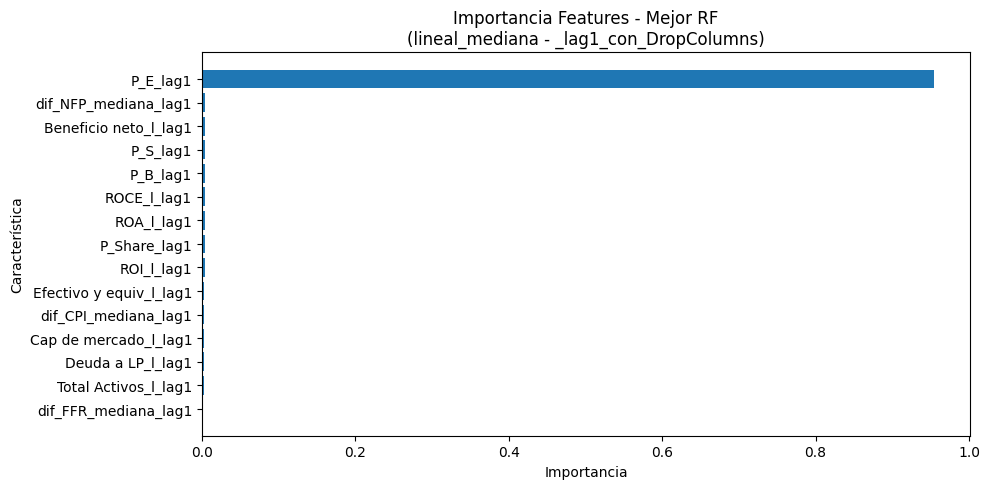

  Mejor XGB para lineal_mediana: RMSE = 16.9601
    Generando importancia de features para Mejor XGB de lineal_mediana...


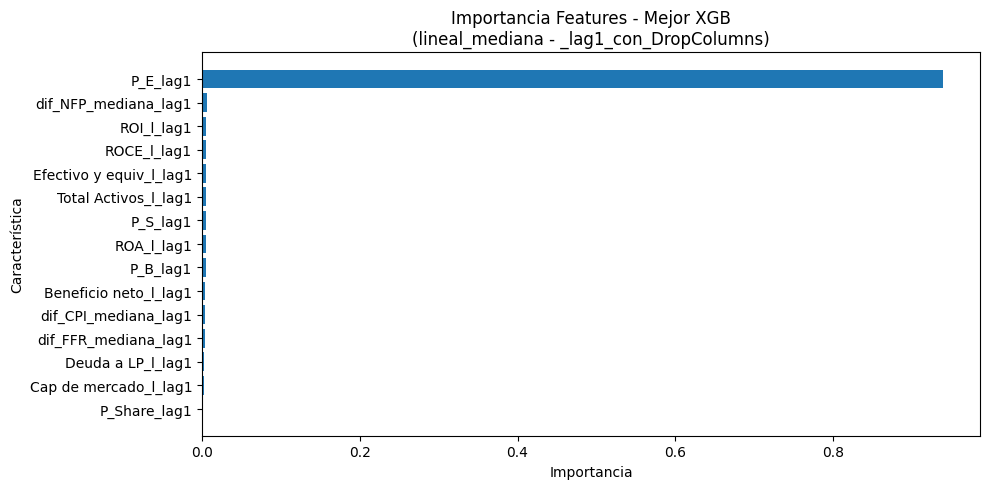

  Mejor LGBM para lineal_mediana: RMSE = 17.2943
    Generando importancia de features para Mejor LGBM de lineal_mediana...


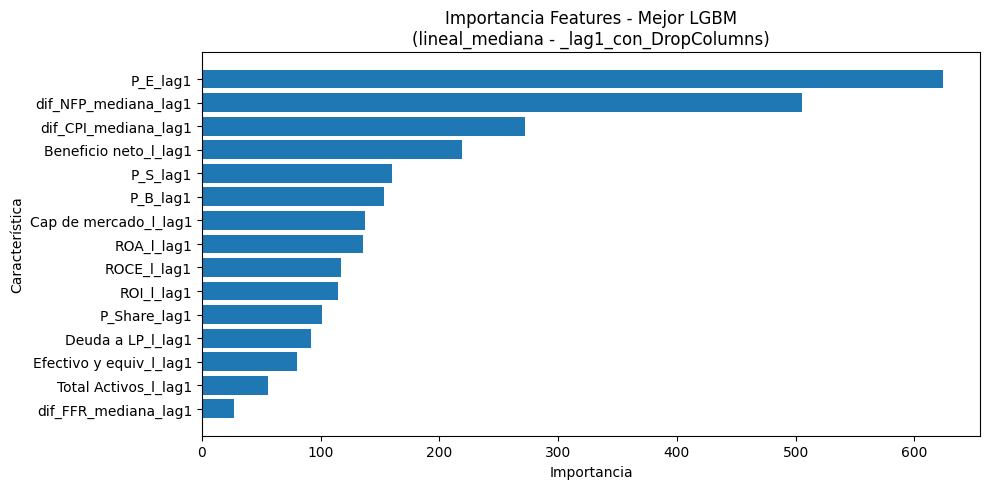

  Mejor CB para lineal_mediana: RMSE = 17.6399
    Generando importancia de features para Mejor CB de lineal_mediana...


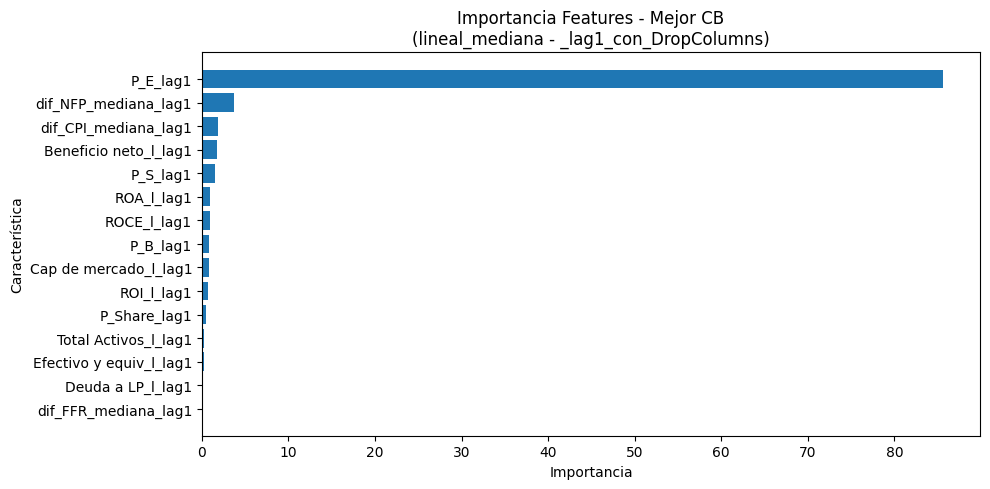


Paquete para 'lineal_mediana' guardado como: paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: spline_mediana ---
  Mejor RF para spline_mediana: RMSE = 14.5923
    Generando importancia de features para Mejor RF de spline_mediana...


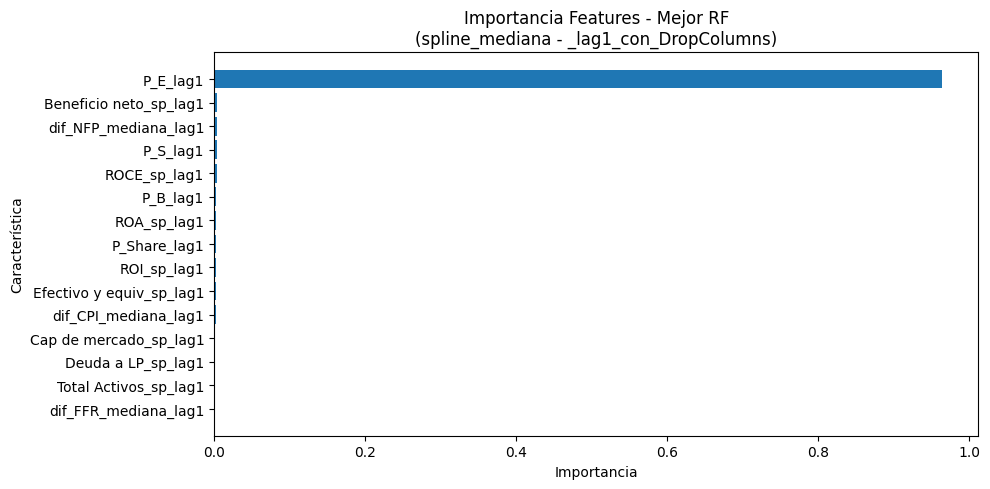

  Mejor XGB para spline_mediana: RMSE = 17.4798
    Generando importancia de features para Mejor XGB de spline_mediana...


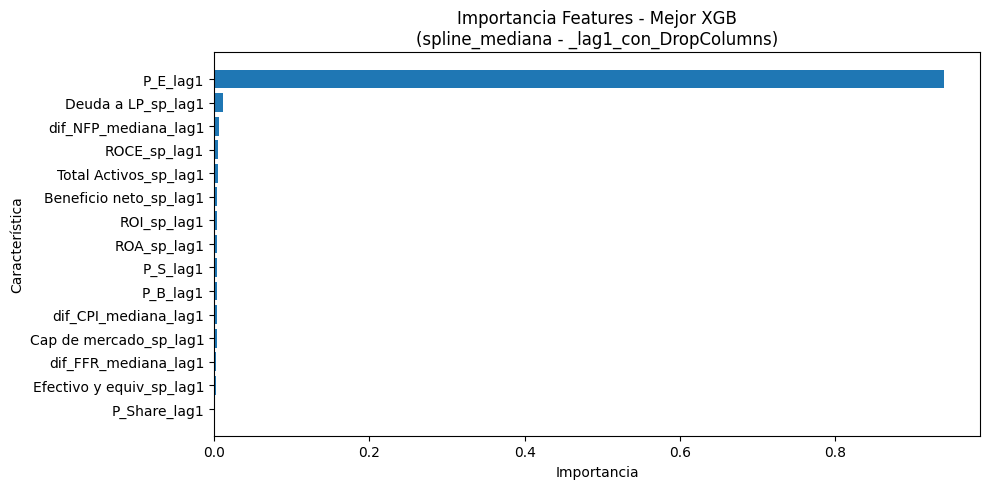

  Mejor LGBM para spline_mediana: RMSE = 18.5791
    Generando importancia de features para Mejor LGBM de spline_mediana...


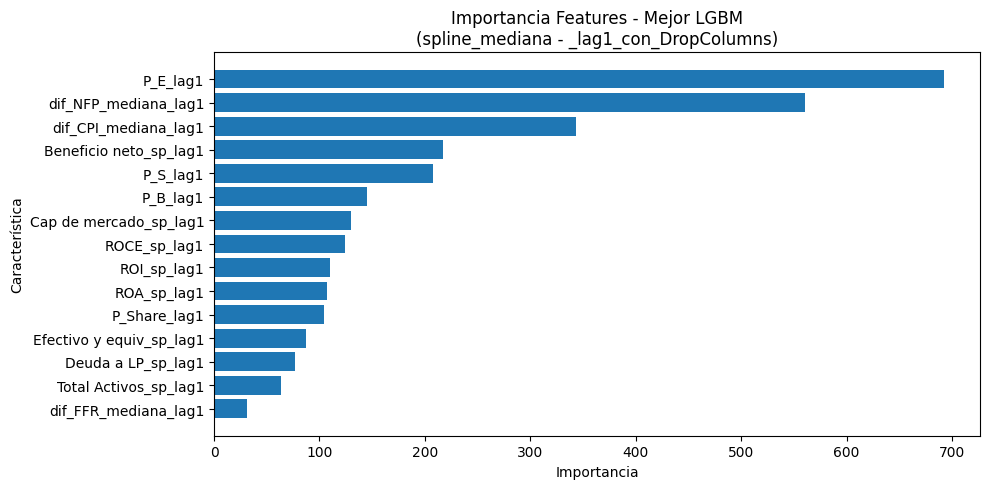

  Mejor CB para spline_mediana: RMSE = 17.5806
    Generando importancia de features para Mejor CB de spline_mediana...


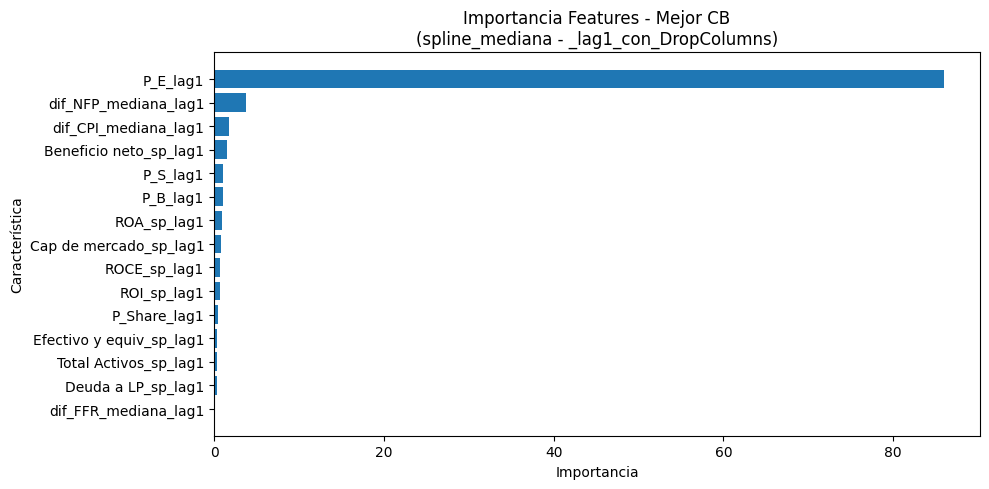


Paquete para 'spline_mediana' guardado como: paquete_mejores_por_tipo_spline_mediana__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: lineal_promedio ---
  Mejor RF para lineal_promedio: RMSE = 14.6557
    Generando importancia de features para Mejor RF de lineal_promedio...


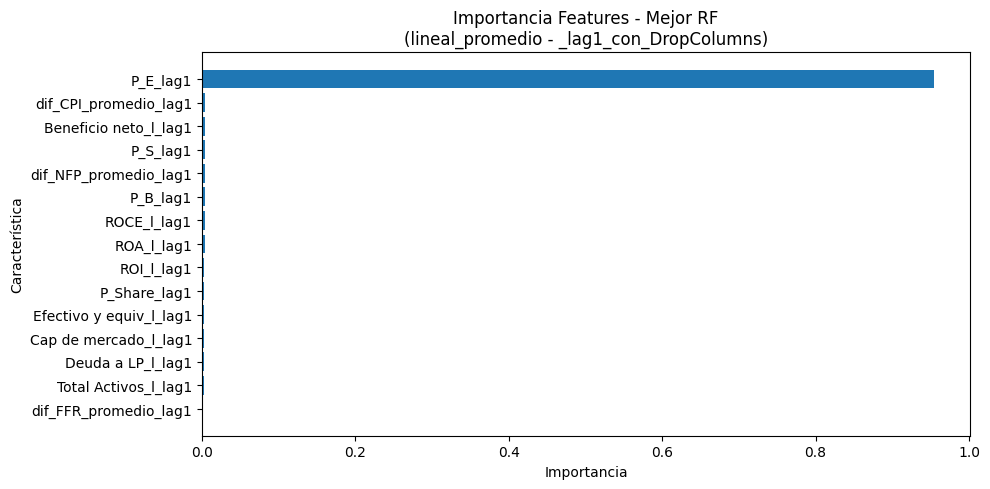

  Mejor XGB para lineal_promedio: RMSE = 19.1276
    Generando importancia de features para Mejor XGB de lineal_promedio...


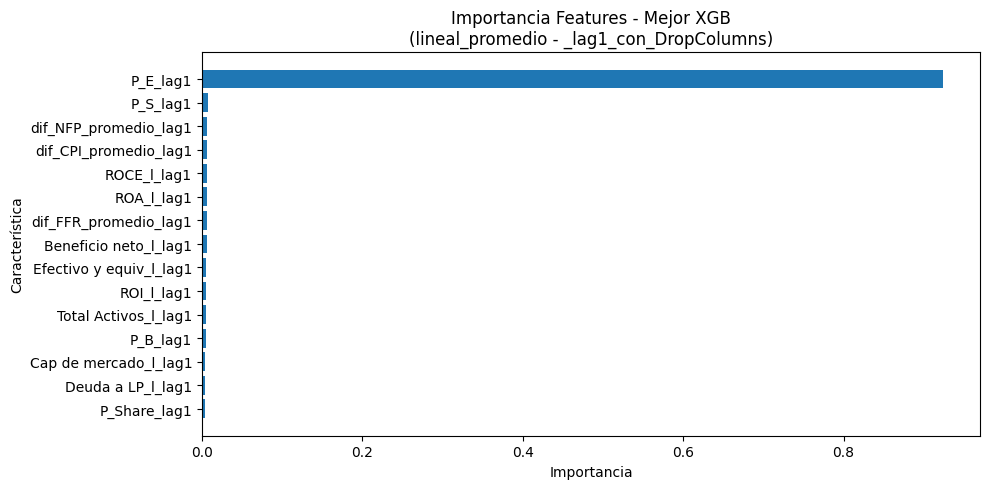

  Mejor LGBM para lineal_promedio: RMSE = 17.6076
    Generando importancia de features para Mejor LGBM de lineal_promedio...


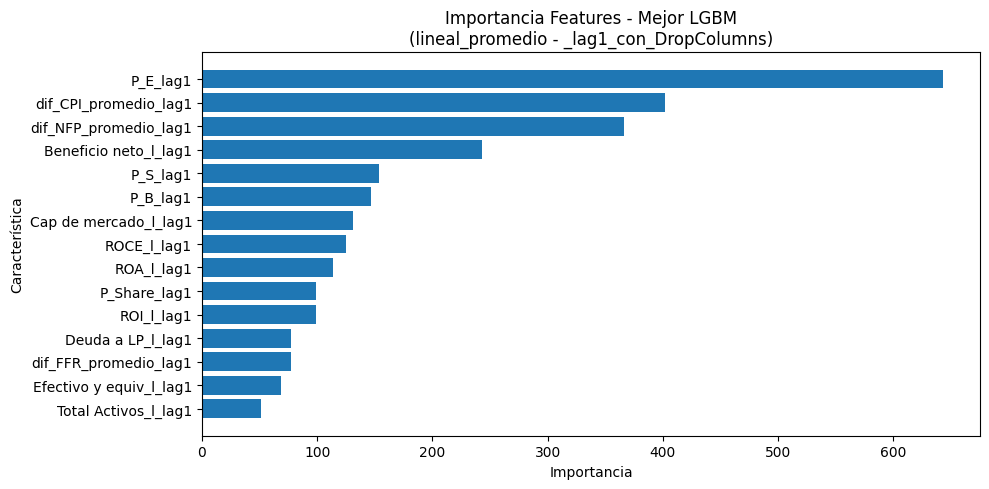

  Mejor CB para lineal_promedio: RMSE = 17.3995
    Generando importancia de features para Mejor CB de lineal_promedio...


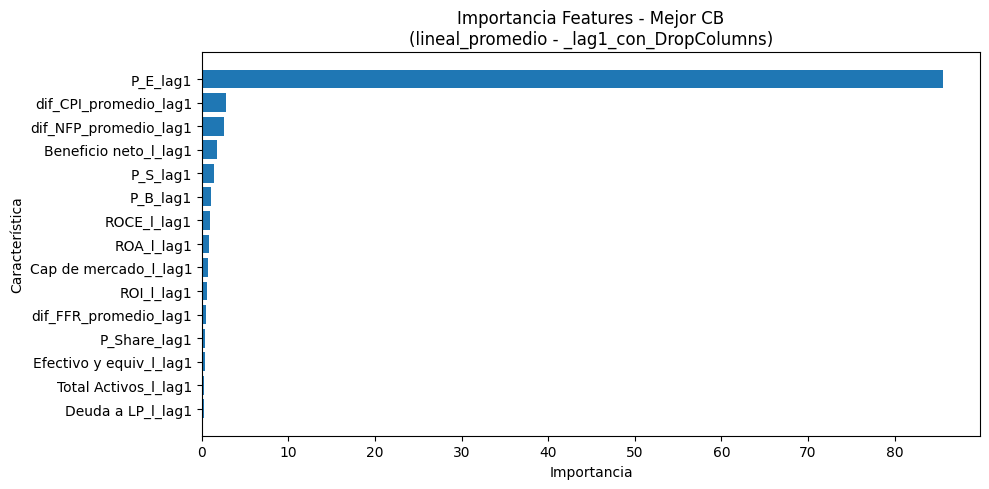


Paquete para 'lineal_promedio' guardado como: paquete_mejores_por_tipo_lineal_promedio__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: spline_promedio ---
  Mejor RF para spline_promedio: RMSE = 14.4751
    Generando importancia de features para Mejor RF de spline_promedio...


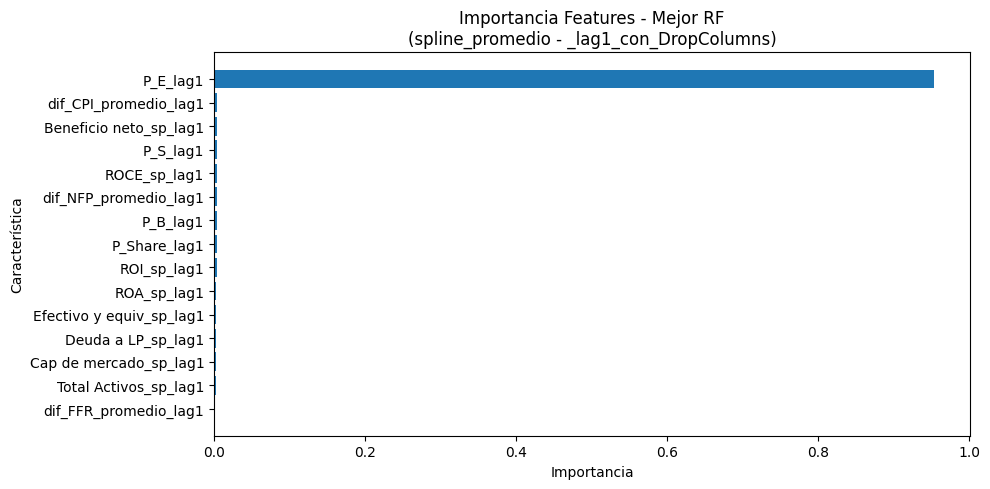

  Mejor XGB para spline_promedio: RMSE = 19.6540
    Generando importancia de features para Mejor XGB de spline_promedio...


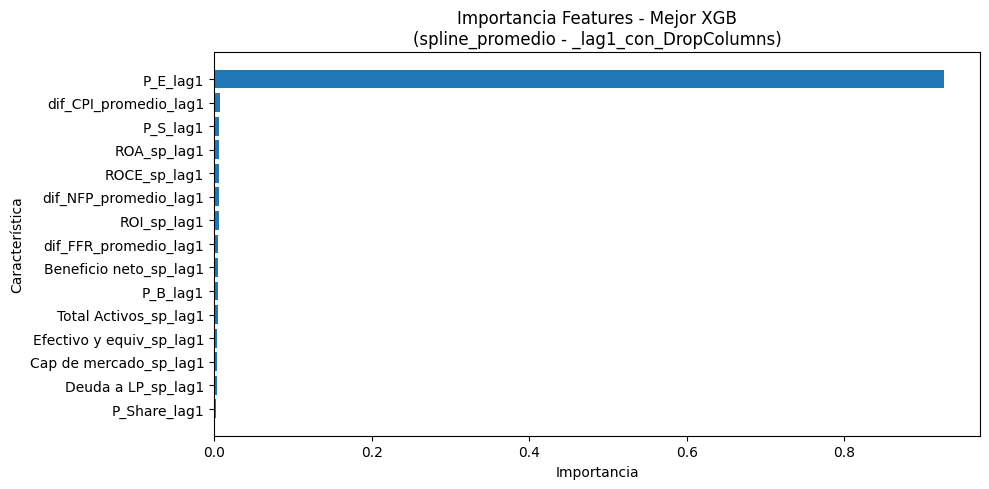

  Mejor LGBM para spline_promedio: RMSE = 18.2325
    Generando importancia de features para Mejor LGBM de spline_promedio...


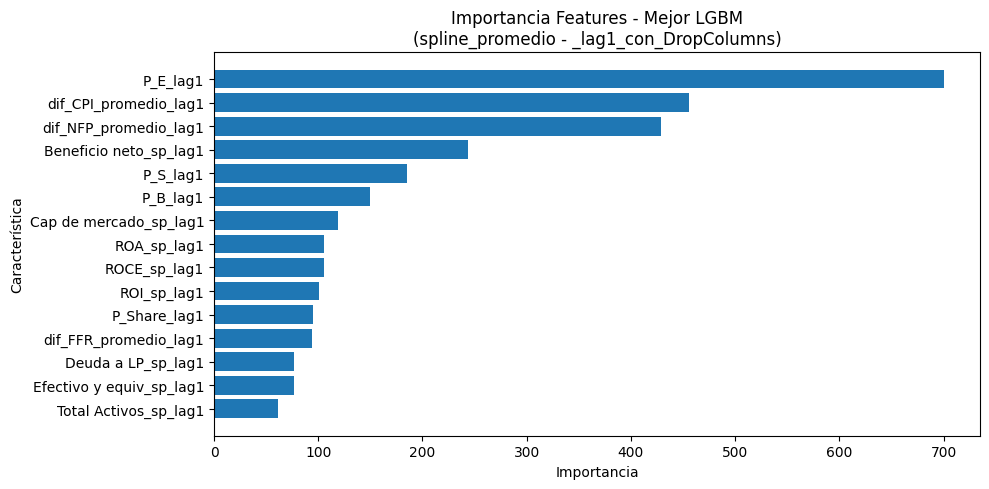

  Mejor CB para spline_promedio: RMSE = 17.6596
    Generando importancia de features para Mejor CB de spline_promedio...


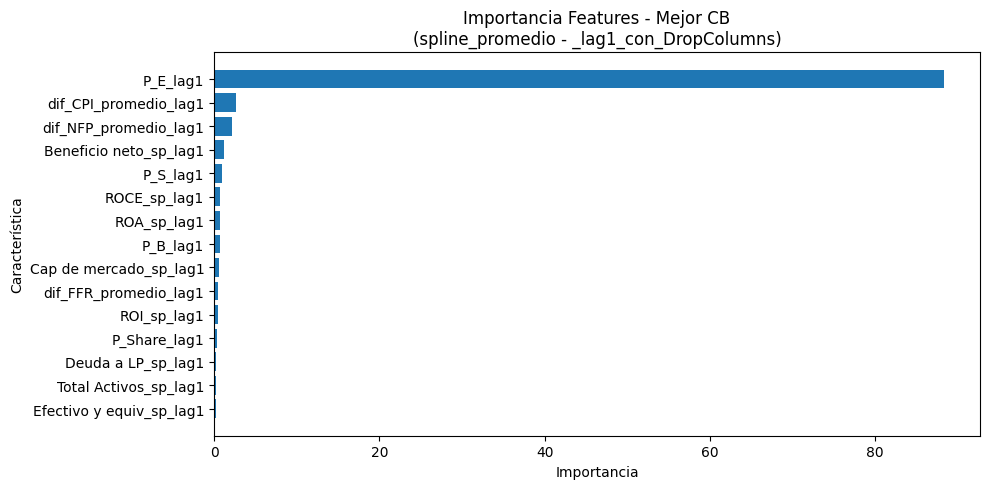


Paquete para 'spline_promedio' guardado como: paquete_mejores_por_tipo_spline_promedio__lag1_con_DropColumns.joblib

TABLA RESUMEN DE LOS MEJORES MODELOS POR TIPO
Metodo_Features            Lag_Config  Log_Transform Modelo_Tipo_Base    RMSE    MAE     R2  n_features_modelo                                                                                               Best_Params
 lineal_mediana _lag1_con_DropColumns           True               RF 14.2395 3.0601 0.7982                 15                                                                                                      None
 lineal_mediana _lag1_con_DropColumns           True              XGB 16.9601 3.1162 0.7137                 15                          {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
 lineal_mediana _lag1_con_DropColumns           True             LGBM 17.2943 3.1895 0.7023                 15 {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators'

In [34]:
# ================================================================================
# BLOQUE DE EXPERIMENTOS (CON DropColumns en Pipeline, PLOT FEATURE IMPORTANCE para Mejores por Tipo, GUARDAR PAQUETES)
# ================================================================================
results_accumulator = [] 
start_time_total_experiments = time.time()
use_log_transform_experiment = True
test_size_ratio_experiment = 0.20
LAG_SUFFIX_TO_USE = '_lag1' 

if 'dfs_shifted' not in locals() or not isinstance(dfs_shifted, dict) or not dfs_shifted:
    raise NameError("El diccionario 'dfs_shifted' no está definido o está vacío.")

for metodo_features, df_original_with_lags_and_ids in dfs_shifted.items():
    start_time_metodo = time.time()
    lag_config_display = f"{LAG_SUFFIX_TO_USE}_con_DropColumns" 

    print("\n" + "="*80)
    print(f"Procesando Método: {metodo_features} {'(CON Log Transform)' if use_log_transform_experiment else '(SIN Log Transform)'} (Lags: {LAG_SUFFIX_TO_USE}, con DropColumns)")
    print("="*80 + "\n")

    if df_original_with_lags_and_ids.empty: continue
    df_current_method_processed = df_original_with_lags_and_ids.copy()
    if 'time_step' not in df_current_method_processed.columns:
        df_current_method_processed.sort_values(['Empresa', 'Fecha'], inplace=True)
        df_current_method_processed['time_step'] = df_current_method_processed.groupby('Empresa').cumcount()

    predictor_cols_for_pipeline_input = sorted([
        c for c in df_current_method_processed.columns 
        if c.endswith(LAG_SUFFIX_TO_USE) and c not in ['Empresa', 'Fecha', 'time_step', 'P_E']
    ])
    if not predictor_cols_for_pipeline_input: continue
    columnas_base_que_generaron_lags = sorted(list(set(re.sub(r'_lag\d+$', '', lag_col) for lag_col in predictor_cols_for_pipeline_input)))
    
    all_relevant_cols_for_df = ['Empresa', 'Fecha', 'time_step', 'P_E'] + predictor_cols_for_pipeline_input
    final_cols_for_df_model_construction = sorted(list(set(c for c in all_relevant_cols_for_df if c in df_current_method_processed.columns)))
    essential_cols_check = ['Empresa', 'Fecha', 'time_step', 'P_E']
    if not all(ec in final_cols_for_df_model_construction for ec in essential_cols_check): continue
    df_model_for_splitting = df_current_method_processed[final_cols_for_df_model_construction].copy()

    n_total_empresas = df_model_for_splitting['Empresa'].nunique()
    n_empresas_test = 0
    if n_total_empresas > 1:
        n_empresas_test = max(1, int(round(n_total_empresas * test_size_ratio_experiment)))
        if n_total_empresas - n_empresas_test < 1 : n_empresas_test = n_total_empresas - 1
    X_train_with_ids, y_train_original, X_test_with_ids, y_test_original = train_test_split_by_empresa(df_model_for_splitting, n_empresas_test)
    if X_train_with_ids is None or X_train_with_ids.empty: continue
    
    y_train_transformed_target = y_train_original.copy()
    if use_log_transform_experiment:
        y_numeric = pd.to_numeric(y_train_original, errors='coerce')
        median_y_train = y_numeric.median() if not y_numeric.isnull().all() else 0.0
        y_numeric = y_numeric.fillna(median_y_train); y_numeric.loc[y_numeric < 0] = 0
        y_train_transformed_target = np.log1p(y_numeric)
        if y_train_transformed_target.isnull().any():
             median_y_transformed = y_train_transformed_target.median() if not y_train_transformed_target.isnull().all() else 0.0
             y_train_transformed_target = y_train_transformed_target.fillna(median_y_transformed)

    if not X_train_with_ids.index.equals(y_train_transformed_target.index):
        common_idx_train = X_train_with_ids.index.intersection(y_train_transformed_target.index)
        X_train_with_ids = X_train_with_ids.loc[common_idx_train]
        y_train_transformed_target = y_train_transformed_target.loc[common_idx_train]
        if X_train_with_ids.empty : continue

    X_train_s_with_ids, y_train_s_transformed = sort_by_timestep(X_train_with_ids, y_train_transformed_target)
    X_test_s_with_ids, y_test_s_original = pd.DataFrame(), pd.Series(dtype=float)
    if X_test_with_ids is not None and not X_test_with_ids.empty:
        X_test_s_with_ids, y_test_s_original = sort_by_timestep(X_test_with_ids, y_test_original)

    param_grid_rf   = {'model__max_depth':[10, 20, None],'model__min_samples_split':[5, 10],'model__n_estimators':[100, 200]}
    param_grid_xgb  = {'model__n_estimators':[100, 200],'model__max_depth':[3, 5, 7],'model__learning_rate':[0.1, 0.05]}
    param_grid_lgbm = {'model__n_estimators':[100, 200],'model__learning_rate':[0.1, 0.05],'model__max_depth':[3, 5, 7],'model__num_leaves':[15, 31]}
    param_grid_cb   = {'model__iterations':[100, 200],'model__learning_rate':[0.1, 0.05],'model__depth':[3, 5, 7],'model__l2_leaf_reg':[1, 3]}
    scenarios = {
        'RF_Simple':  {'model': RandomForestRegressor(random_state=42, n_jobs=-1), 'hp': False, 'vt': False, 'grid': param_grid_rf},
        'RF_HP':      {'model': RandomForestRegressor(random_state=42, n_jobs=-1), 'hp': True,  'vt': False, 'grid': param_grid_rf},
        'XGB_Simple': {'model': XGBRegressor(random_state=42, n_jobs=-1), 'hp': False, 'vt': False, 'grid': param_grid_xgb},
        'XGB_HP':     {'model': XGBRegressor(random_state=42, n_jobs=-1), 'hp': True,  'vt': False, 'grid': param_grid_xgb},
        'LGBM_Simple':{'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1), 'hp': False, 'vt': False, 'grid': param_grid_lgbm},
        'LGBM_HP':    {'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1), 'hp': True,  'vt': False, 'grid': param_grid_lgbm},
        'CB_Simple':  {'model': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False), 'hp': False, 'vt': False, 'grid': param_grid_cb},
        'CB_HP':      {'model': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False), 'hp': True,  'vt': False, 'grid': param_grid_cb},
    }

    for escenario_nombre, escenario_cfg in scenarios.items():
        tiempo_esc_inicio = time.time()
        current_base_model = escenario_cfg['model']; perform_hp_search = escenario_cfg['hp']; use_temporal_cv_in_scenario = escenario_cfg.get('vt', False)
        X_fit_data_pipeline = X_train_s_with_ids if use_temporal_cv_in_scenario else X_train_with_ids
        y_fit_data_pipeline = y_train_s_transformed if use_temporal_cv_in_scenario else y_train_transformed_target
        X_eval_data_pipeline = X_test_s_with_ids if use_temporal_cv_in_scenario else X_test_with_ids
        y_eval_data_original_final = y_test_s_original if use_temporal_cv_in_scenario else y_test_original
        if X_fit_data_pipeline.empty or y_fit_data_pipeline.empty:
            results_accumulator.append({'Modelo': escenario_nombre.split('_')[0], 'Validacion_Temp': use_temporal_cv_in_scenario,
                'Busqueda_HP': perform_hp_search, 'Config_Key': metodo_features, 'Metodo': metodo_features,
                'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 'RMSE': np.nan, 'MAE': np.nan, 
                'R2': np.nan, 'Best_Params': None, 'pipeline': 'Error: Datos vacíos', 
                'columnas_base_usadas': columnas_base_que_generaron_lags, 
                'n_features_modelo': len(predictor_cols_after_drop), 
                'features_usadas_por_modelo': [], 'Error': 'Datos vacíos'})
            continue
        cols_to_drop_in_pipeline = [col for col in ['Empresa', 'Fecha', 'time_step'] if col in X_fit_data_pipeline.columns]
        pipeline_obj_for_training = Pipeline([('drop_ids', DropColumns(columns=cols_to_drop_in_pipeline)), ('model', current_base_model)])
        model_actual_features_for_plot = [col for col in X_fit_data_pipeline.columns if col not in cols_to_drop_in_pipeline]
        final_fitted_pipeline, hp_best_params_found, error_msg_escenario = None, None, None
        try:
            if perform_hp_search:
                cv_strategy_obj, cv_fit_params_dict, can_perform_cv = None, {}, True
                n_groups_for_cv = X_fit_data_pipeline['Empresa'].nunique() if use_temporal_cv_in_scenario and 'Empresa' in X_fit_data_pipeline.columns else 0
                if use_temporal_cv_in_scenario and n_groups_for_cv >= 2:
                    groups_for_gkf = X_fit_data_pipeline['Empresa']; n_splits_gkf = min(3, n_groups_for_cv); n_splits_gkf = max(2, n_splits_gkf)
                    if len(X_fit_data_pipeline) < n_splits_gkf : can_perform_cv = False
                    else: cv_strategy_obj = GroupKFold(n_splits=n_splits_gkf); cv_fit_params_dict = {'groups': groups_for_gkf}
                elif len(X_fit_data_pipeline) >= 2:
                    n_samples_kf = len(X_fit_data_pipeline); kfold_splits_val = min(3, n_samples_kf); kfold_splits_val = max(2, kfold_splits_val)
                    if n_samples_kf < kfold_splits_val : can_perform_cv = False
                    else: cv_strategy_obj = KFold(n_splits=kfold_splits_val, shuffle=True, random_state=42)
                else: can_perform_cv = False
                if not can_perform_cv or cv_strategy_obj is None: perform_hp_search = False
                if perform_hp_search:
                    gs = GridSearchCV(pipeline_obj_for_training, escenario_cfg['grid'], scoring=rmse_scorer, cv=cv_strategy_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                    gs.fit(X_fit_data_pipeline, y_fit_data_pipeline, **cv_fit_params_dict)
                    final_fitted_pipeline, hp_best_params_found = gs.best_estimator_, gs.best_params_
            if not perform_hp_search or final_fitted_pipeline is None:
                pipeline_obj_for_training.fit(X_fit_data_pipeline, y_fit_data_pipeline)
                final_fitted_pipeline = pipeline_obj_for_training; hp_best_params_found = None
        except Exception as e: error_msg_escenario = str(e)
        eval_metrics_dict, n_features_in_final_model_attr = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}, "N/A"
        if final_fitted_pipeline:
            try:
                actual_estimator = final_fitted_pipeline.steps[-1][1]
                n_features_in_final_model_attr = getattr(actual_estimator, 'n_features_in_', "N/A")
                if not X_eval_data_pipeline.empty and not y_eval_data_original_final.empty:
                    pred_transformed_eval = final_fitted_pipeline.predict(X_eval_data_pipeline)
                    pred_original_scale_eval = np.expm1(pred_transformed_eval) if use_log_transform_experiment else pred_transformed_eval
                    if use_log_transform_experiment: pred_original_scale_eval[~np.isfinite(pred_original_scale_eval)] = np.nan
                    eval_metrics_dict = evaluate_model(y_eval_data_original_final, pred_original_scale_eval)
                    print(f"    Métricas Test {escenario_nombre}: RMSE={eval_metrics_dict['RMSE']:.4f}, MAE={eval_metrics_dict['MAE']:.4f}, R2={eval_metrics_dict['R2']:.4f}")
                # NO PLOTEAMOS AQUÍ, LO HAREMOS AL FINAL PARA LOS MEJORES POR TIPO
            except Exception as e_eval: error_msg_escenario = (error_msg_escenario + f" | EvalError: {str(e_eval)}") if error_msg_escenario else f"EvalError: {str(e_eval)}"
        
        results_accumulator.append({
            'Modelo': escenario_nombre.split('_')[0], 'Validacion_Temp': use_temporal_cv_in_scenario and isinstance(cv_strategy_obj, GroupKFold),
            'Busqueda_HP': escenario_cfg['hp'] and perform_hp_search, 
            'Config_Key': metodo_features, 'Metodo': metodo_features, 
            'Lag_Config': lag_config_display, 
            'Log_Transform': use_log_transform_experiment, 
            'RMSE': eval_metrics_dict['RMSE'], 'MAE': eval_metrics_dict['MAE'], 'R2': eval_metrics_dict['R2'], 
            'Best_Params': hp_best_params_found, 
            'pipeline': final_fitted_pipeline, 
            'columnas_base_usadas': columnas_base_que_generaron_lags, 
            'n_features_modelo': n_features_in_final_model_attr, 
            'features_usadas_por_modelo': model_actual_features_for_plot, # Guardar las features que vio el estimador
            'Error': error_msg_escenario
        })
    print(f"\nTiempo total para Método: {metodo_features}: {time.time() - start_time_metodo:.2f}s")
print(f"\n\nTiempo total de ejecución de todos los experimentos: {(time.time() - start_time_total_experiments)/60:.2f} minutos")

# ================================================================================
# CREAR TABLA DE RESULTADOS GENERAL, GUARDAR PAQUETES Y PLOTEAR MEJORES POR TIPO
# ================================================================================
if results_accumulator:
    df_results_all_experiments = pd.DataFrame(results_accumulator)
    print("\n" + "="*80 + "\n--- Resultados Finales Globales ---\n" + f"Total resultados: {len(df_results_all_experiments)}\n")
    cols_to_display_summary = ['Metodo', 'Modelo', 'Busqueda_HP', 'RMSE', 'MAE', 'R2', 'n_features_modelo', 'Lag_Config', 'Error', 'Best_Params'] # Quitado 'features_usadas_por_modelo' para brevedad
    final_cols_to_display_summary = [col for col in cols_to_display_summary if col in df_results_all_experiments.columns]
    with pd.option_context('display.max_rows', 200, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
        print(df_results_all_experiments.sort_values(by=['Metodo','RMSE'], ascending=[True,True])[final_cols_to_display_summary].to_string(index=False))

    lista_info_mejores_por_tipo_global = []
    for metodo_actual_features_key in df_results_all_experiments['Metodo'].unique(): 
        print("\n" + "="*70 + f"\n--- Preparando paquete y plots para Método: {metodo_actual_features_key} ---")
        df_resultados_metodo_actual = df_results_all_experiments[
            (df_results_all_experiments['Metodo'] == metodo_actual_features_key) &
            (df_results_all_experiments['RMSE'].notna()) &
            (df_results_all_experiments['pipeline'].notna()) & 
            (df_results_all_experiments['Error'].isna()) &
            (df_results_all_experiments['pipeline'].apply(lambda x: not (isinstance(x, str) and x.startswith('Error:')))) & # Asegurar que pipeline no sea string de error
            (df_results_all_experiments['features_usadas_por_modelo'].apply(lambda x: isinstance(x, list) and len(x) > 0)) # Asegurar que hay features
        ].copy()

        if df_resultados_metodo_actual.empty: 
            print(f"No hay resultados válidos con features para el método '{metodo_actual_features_key}' para crear paquete o plotear.")
            continue

        mejores_modelos_info_para_paquete = {}
        modelos_base_a_considerar = ['RF', 'XGB', 'LGBM', 'CB']
        
        metadata_ref_row = df_resultados_metodo_actual.iloc[0]
        log_transform_paquete_actual = metadata_ref_row.get('Log_Transform', True)
        columnas_base_paquete_actual = metadata_ref_row.get('columnas_base_usadas', []) 
        lag_config_paquete_actual = metadata_ref_row.get('Lag_Config', 'desconocida')
        
        for tipo_modelo_base in modelos_base_a_considerar:
            df_tipo_especifico = df_resultados_metodo_actual[df_resultados_metodo_actual['Modelo'] == tipo_modelo_base]
            if not df_tipo_especifico.empty:
                mejor_fila_tipo_actual = df_tipo_especifico.sort_values(by='RMSE', ascending=True).iloc[0]
                
                pipeline_obj_actual = mejor_fila_tipo_actual['pipeline']
                features_usadas_actual = mejor_fila_tipo_actual['features_usadas_por_modelo']

                mejores_modelos_info_para_paquete[tipo_modelo_base] = {
                    'pipeline_object': pipeline_obj_actual,
                    'RMSE': mejor_fila_tipo_actual['RMSE'], 'MAE': mejor_fila_tipo_actual['MAE'],
                    'R2': mejor_fila_tipo_actual['R2'], 'Best_Params': mejor_fila_tipo_actual['Best_Params'],
                    'n_features_modelo': mejor_fila_tipo_actual['n_features_modelo'],
                    'features_usadas_por_modelo': features_usadas_actual, 
                    'Escenario_Validacion_Temp': mejor_fila_tipo_actual['Validacion_Temp'],
                    'Escenario_Busqueda_HP': mejor_fila_tipo_actual['Busqueda_HP']}
                
                print(f"  Mejor {tipo_modelo_base} para {metodo_actual_features_key}: RMSE = {mejor_fila_tipo_actual['RMSE']:.4f}")

                # --- PLOT FEATURE IMPORTANCE PARA ESTE MEJOR MODELO POR TIPO ---
                titulo_plot_tipo = (
                    f"Importancia Features - Mejor {tipo_modelo_base}\n"
                    f"({metodo_actual_features_key} - {lag_config_paquete_actual})"
                )
                print(f"    Generando importancia de features para Mejor {tipo_modelo_base} de {metodo_actual_features_key}...")
                plot_feature_importances(
                    pipeline_obj_actual, # El pipeline completo (DropColumns + modelo)
                    feature_names=features_usadas_actual, # Las features que vio el estimador final
                    title=titulo_plot_tipo
                )
                # --- FIN PLOT ---

                info_para_tabla_resumen = {
                    'Metodo_Features': metodo_actual_features_key, 
                    'Lag_Config': lag_config_paquete_actual,
                    'Log_Transform': log_transform_paquete_actual, 
                    'Modelo_Tipo_Base': tipo_modelo_base,
                    'RMSE': mejor_fila_tipo_actual['RMSE'], 'MAE': mejor_fila_tipo_actual['MAE'],
                    'R2': mejor_fila_tipo_actual['R2'], 'n_features_modelo': mejor_fila_tipo_actual['n_features_modelo'],
                    'Best_Params': mejor_fila_tipo_actual['Best_Params']}
                lista_info_mejores_por_tipo_global.append(info_para_tabla_resumen)
            else: 
                mejores_modelos_info_para_paquete[tipo_modelo_base] = None 

        if any(mejores_modelos_info_para_paquete.values()):
            paquete_final_a_guardar = {
                'metodo_features': metodo_actual_features_key, 
                'lag_config_usada': lag_config_paquete_actual,
                'log_transform_target': log_transform_paquete_actual,
                'columnas_base_para_lags': columnas_base_paquete_actual, 
                'mejores_modelos_info_por_tipo': mejores_modelos_info_para_paquete
            }
            nombre_archivo_paquete_final = f"paquete_mejores_por_tipo_{metodo_actual_features_key.replace(' ', '_')}_{lag_config_paquete_actual}.joblib"
            try:
                joblib.dump(paquete_final_a_guardar, nombre_archivo_paquete_final)
                print(f"\nPaquete para '{metodo_actual_features_key}' guardado como: {nombre_archivo_paquete_final}")
            except Exception as e_dump_final_package: print(f"\nERROR al guardar paquete para '{metodo_actual_features_key}': {e_dump_final_package}")
    
    if lista_info_mejores_por_tipo_global:
        df_mejores_por_tipo_global = pd.DataFrame(lista_info_mejores_por_tipo_global)
        print("\n" + "="*80 + "\nTABLA RESUMEN DE LOS MEJORES MODELOS POR TIPO" + "\n" + "="*80)
        with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
            cols_resumen_mejores = ['Metodo_Features', 'Lag_Config', 'Log_Transform', 'Modelo_Tipo_Base', 'RMSE', 'MAE', 'R2', 'n_features_modelo', 'Best_Params']
            cols_resumen_existentes = [col for col in cols_resumen_mejores if col in df_mejores_por_tipo_global.columns]
            print(df_mejores_por_tipo_global.sort_values(by=['Metodo_Features', 'RMSE'], ascending=[True, True])[cols_resumen_existentes].to_string(index=False))
else: 
    print("\nNo se generaron resultados en los experimentos.")

In [35]:
df_mejores_por_tipo_global.sort_values(by=['Metodo_Features', 'RMSE'], ascending=[True, True])

,Metodo_Features,Lag_Config,Log_Transform,Modelo_Tipo_Base,RMSE,MAE,R2,n_features_modelo,Best_Params
0,lineal_mediana,_lag1_con_DropColumns,True,RF,14.239522,3.060087,0.798209,15,None
1,lineal_mediana,_lag1_con_DropColumns,True,XGB,16.960096,3.116198,0.713735,15,"{'model__learning_rate': 0.1, 'model__max_dept..."
2,lineal_mediana,_lag1_con_DropColumns,True,LGBM,17.294285,3.189464,0.702343,15,"{'model__learning_rate': 0.1, 'model__max_dept..."
3,lineal_mediana,_lag1_con_DropColumns,True,CB,17.639887,3.162464,0.690327,15,"{'model__depth': 7, 'model__iterations': 200, ..."
8,lineal_promedio,_lag1_con_DropColumns,True,RF,14.655709,3.034839,0.786241,15,None
11,lineal_promedio,_lag1_con_DropColumns,True,CB,17.399527,3.177163,0.698709,15,"{'model__depth': 7, 'model__iterations': 200, ..."
10,lineal_promedio,_lag1_con_DropColumns,True,LGBM,17.607562,3.186511,0.691461,15,"{'model__learning_rate': 0.1, 'model__max_dept..."
9,lineal_promedio,_lag1_con_DropColumns,True,XGB,19.127575,3.291315,0.635891,15,"{'model__learning_rate': 0.1, 'model__max_dept..."
4,spline_mediana,_lag1_con_DropColumns,True,RF,14.592253,3.018516,0.788088,15,"{'model__max_depth': None, 'model__min_samples..."
5,spline_mediana,_lag1_con_DropColumns,True,XGB,17.479843,3.183617,0.695921,15,"{'model__learning_rate': 0.1, 'model__max_dept..."


Cargando paquete de modelos desde: paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib
Paquete de modelos cargado exitosamente.
  Información del Paquete: Método=lineal_mediana, LagConfig=_lag1_con_DropColumns, LogT=True
    Columnas Base (usadas para generar lags): 15 ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a LP_l', 'Efectivo y equiv_l', 'P_B']...
    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.
Se generarán lags [1] para DLocal.

Preparando datos de DLocal (Método: lineal_mediana, Lags: [1])
Generando lags para DLocal para las features: ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a LP_l', 'Efectivo y equiv_l', 'P_B', 'P_E', 'P_S', 'P_Share', 'ROA_l', 'ROCE_l', 'ROI_l', 'Total Activos_l', 'dif_CPI_mediana', 'dif_FFR_mediana', 'dif_NFP_mediana']
Se generaron 15 columnas de lag para DLocal: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
    ¡Confirmado! L

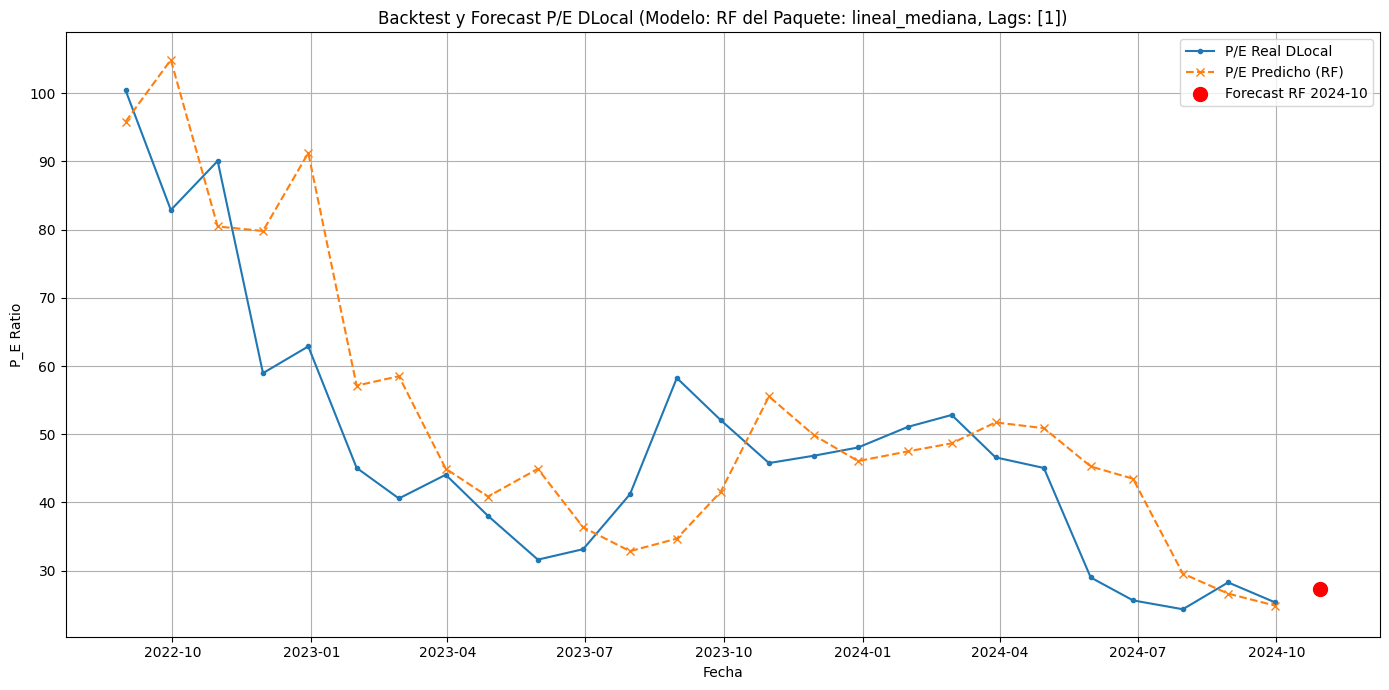


--- Procesando Modelo Tipo: XGB ---
  Features esperadas por XGB (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (XGB): RMSE=13.5250, MAE=10.2346, R2=0.4874


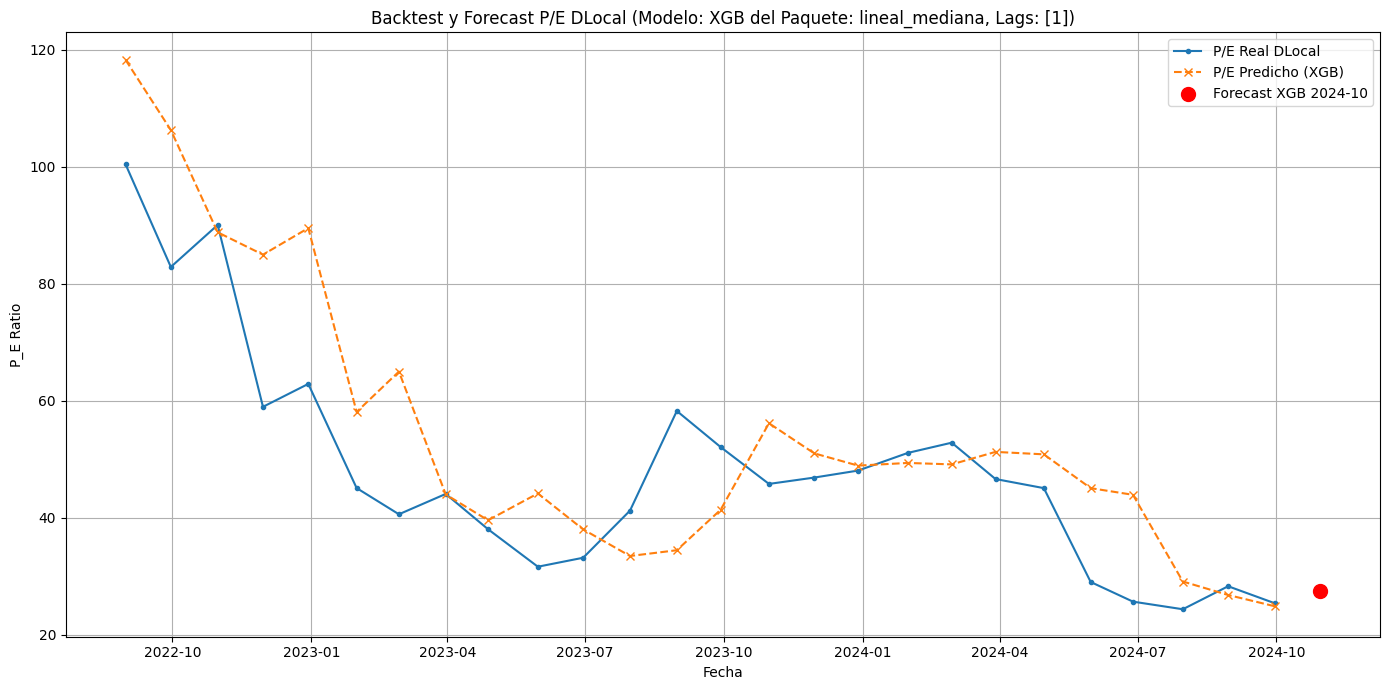


--- Procesando Modelo Tipo: LGBM ---
  Features esperadas por LGBM (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (LGBM): RMSE=14.7007, MAE=10.8001, R2=0.3944


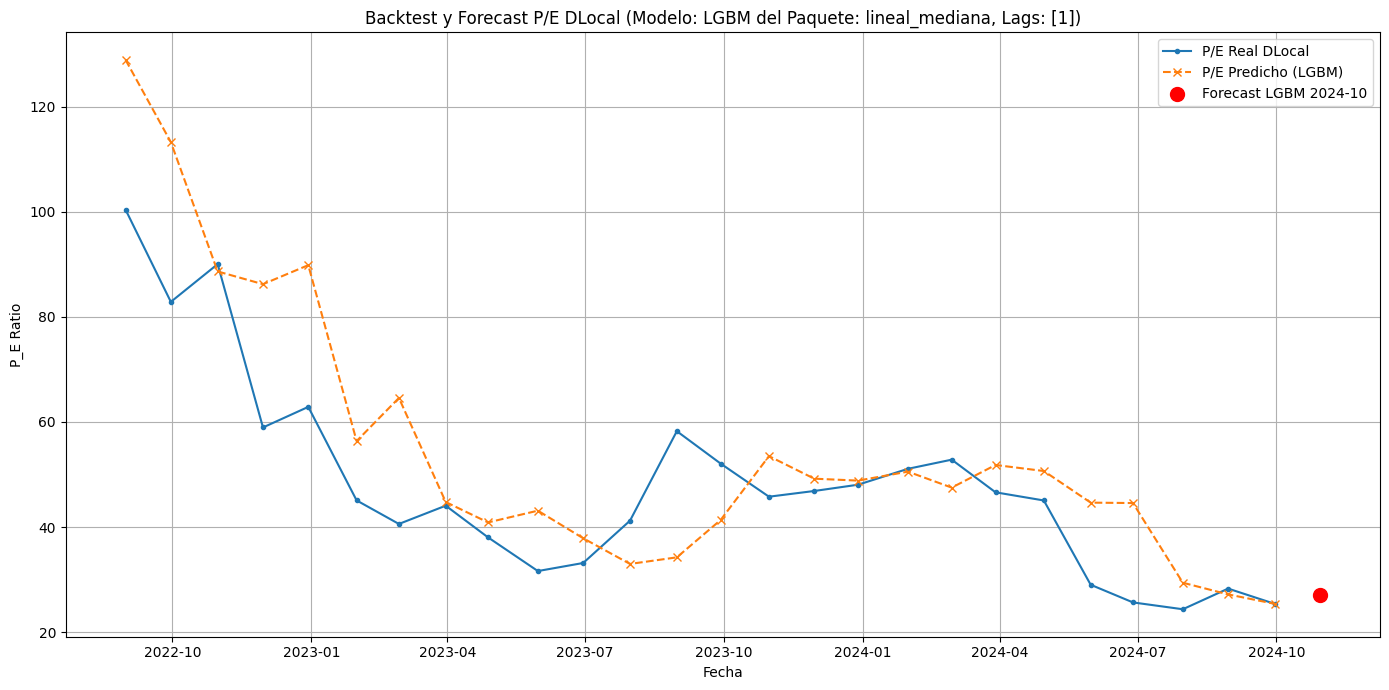


--- Procesando Modelo Tipo: CB ---
  Features esperadas por CB (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (CB): RMSE=13.9122, MAE=10.5779, R2=0.4576


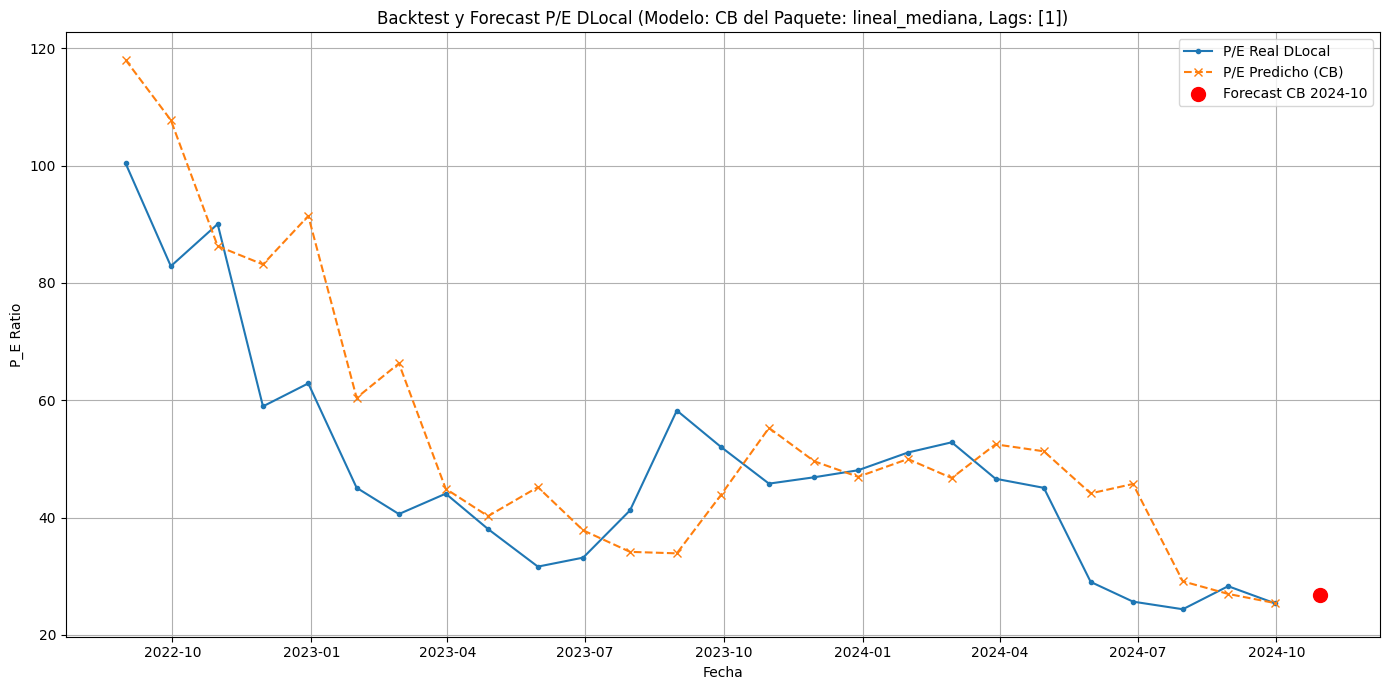


Resumen de Métricas Individuales de los Modelos en el Backtest de DLocal
Modelo_Tipo    RMSE     MAE     R2
         RF 12.4728  9.7274 0.5641
        XGB 13.5250 10.2346 0.4874
         CB 13.9122 10.5779 0.4576
       LGBM 14.7007 10.8001 0.3944

Proceso de predicción para DLocal completado.


In [37]:
# =====================================================================================
# BLOQUE DE PREDICCIÓN PARA DLOCAL (MODELOS INDIVIDUALES - GRÁFICOS Y MÉTRICAS)
# =====================================================================================

# --- 0. CONFIGURACIÓN Y CARGA DEL PAQUETE DEL MODELO ---
# ASUME: df_dlocal está cargado.
#        listas_columnas está definida (si es necesaria como fallback para columnas_base_paquete).
#        El paquete fue entrenado incluyendo P_E_lagN como feature si se desea usar aquí.

nombre_paquete_a_cargar = "paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib"

print(f"Cargando paquete de modelos desde: {nombre_paquete_a_cargar}")
model_package = None
try:
    ruta_paquete = os.path.join(os.getcwd(), nombre_paquete_a_cargar)
    if not os.path.exists(ruta_paquete):
        raise FileNotFoundError(f"El archivo del paquete '{ruta_paquete}' no existe.")
    model_package = joblib.load(ruta_paquete)
    print("Paquete de modelos cargado exitosamente.")

    required_keys = ['metodo_features', 'lag_config_usada', 'log_transform_target', 'mejores_modelos_info_por_tipo']
    if not isinstance(model_package, dict) or not all(key in model_package for key in required_keys):
        raise ValueError("El archivo cargado no es un paquete de modelos válido o le faltan claves esenciales.")

    metodo_features_paquete = model_package['metodo_features']
    lag_config_paquete = model_package['lag_config_usada'] 
    log_transform_paquete = model_package['log_transform_target']
    columnas_base_paquete = model_package.get('columnas_base_para_lags') # Esta clave debe existir en tu paquete
    mejores_modelos_info = model_package['mejores_modelos_info_por_tipo']

    if not columnas_base_paquete: # Fallback si no está en el paquete
        print("ADVERTENCIA: 'columnas_base_para_lags' no encontrada en el paquete. Intentando usar 'listas_columnas'.")
        if 'listas_columnas' in locals() and metodo_features_paquete in listas_columnas:
            columnas_base_paquete = listas_columnas[metodo_features_paquete]
            # Si P_E_lagN se usó y 'P_E' no está en listas_columnas[metodo_features_paquete], hay que añadirlo:
            # Esta lógica asume que si P_E_lagN es una feature, 'P_E' debe estar en las bases para generar ese lag.
            # El paquete idealmente ya tendría 'P_E' en 'columnas_base_para_lags' si P_E_lagN fue usado.
            # Si el paquete es de "solo lags de P/E", columnas_base_paquete debería ser ['P_E'].
            if 'P_E' not in columnas_base_paquete and any(f.startswith("P_E_lag") for f_dict in mejores_modelos_info.values() if f_dict and 'features_usadas_por_modelo' in f_dict for f in f_dict['features_usadas_por_modelo']):
                 if 'P_E' in df_dlocal.columns:
                    print("Añadiendo 'P_E' a columnas_base_paquete para generar su lag, basado en features de modelos.")
                    columnas_base_paquete.append('P_E')
                    columnas_base_paquete = sorted(list(set(columnas_base_paquete)))
        else: 
            raise ValueError("No se pudieron determinar las 'columnas_base_para_lags' ni del paquete ni de 'listas_columnas'.")
    
    print(f"  Información del Paquete: Método={metodo_features_paquete}, LagConfig={lag_config_paquete}, LogT={log_transform_paquete}")
    print(f"    Columnas Base (usadas para generar lags): {len(columnas_base_paquete)} {columnas_base_paquete[:5]}...")
    if 'P_E' in columnas_base_paquete:
        print("    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.")
    else:
        print("    ADVERTENCIA: 'P_E' NO está en columnas_base_paquete. NO se generará P_E_lagN como feature para DLocal, a menos que lag_config_paquete lo fuerce.")

except FileNotFoundError: raise FileNotFoundError(f"ERROR FATAL: No se encontró el archivo del paquete '{nombre_paquete_a_cargar}'.")
except Exception as e_load_pack: raise RuntimeError(f"Error fatal al cargar o procesar el paquete: {e_load_pack}")

if 'df_dlocal' not in locals() or not isinstance(df_dlocal, pd.DataFrame) or df_dlocal.empty:
     raise NameError("'df_dlocal' no definido o vacío.")

# Determinar qué lags generar para DLocal basado en lag_config_paquete
lags_a_generar_dlocal = []
temp_lag_str_cfg = str(lag_config_paquete).lower()
temp_lag_str_cfg = temp_lag_str_cfg.replace('pe_lags_', '').replace('_solo_pred', '').replace('lags_', '').replace('lag', '')
found_numbers_cfg = re.findall(r'\d+', temp_lag_str_cfg)
if found_numbers_cfg:
    lags_a_generar_dlocal = sorted(list(set(int(num) for num in found_numbers_cfg)))
if not lags_a_generar_dlocal: # Fallback
    for i in range(1, 7): 
        if f"lag{i}" in str(lag_config_paquete).lower() or f"_{i}" in str(lag_config_paquete): 
            lags_a_generar_dlocal.append(i)
    lags_a_generar_dlocal = sorted(list(set(lags_a_generar_dlocal)))
if not lags_a_generar_dlocal:
    raise ValueError(f"No se pudo determinar qué lags numéricos generar a partir de lag_config_paquete: '{lag_config_paquete}'")
print(f"Se generarán lags {lags_a_generar_dlocal} para DLocal.")


# --- 1. PREPARAR df_dlocal ---
print("\n" + "="*80 + f"\nPreparando datos de DLocal (Método: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})" + "\n" + "="*80)
df_dlocal_procesado_base = df_dlocal.copy()

# 1.1 Conversión Numérica
# Usar 'columnas_base_paquete' que ahora debería incluir 'P_E' si P_E_lagN es una feature.
cols_convertir_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
for col in cols_convertir_dlocal:
    if not pd.api.types.is_numeric_dtype(df_dlocal_procesado_base[col]):
        df_dlocal_procesado_base[col] = pd.to_numeric(df_dlocal_procesado_base[col], errors='coerce')

# 1.2 Imputación Pre-Lag
cols_imputar_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
if cols_imputar_dlocal:
    df_dlocal_procesado_base.sort_values(['Empresa', 'Fecha'], inplace=True)
    if df_dlocal_procesado_base['Empresa'].nunique() > 1:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base.groupby('Empresa')[cols_imputar_dlocal].ffill()
    else:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].ffill()
    df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].fillna(0)

# 1.3 Generar Lags
# 'features_para_generar_lags_dlocal' se basa en 'columnas_base_paquete'
features_para_generar_lags_dlocal = [c for c in columnas_base_paquete if c in df_dlocal_procesado_base.columns]
# Asegurar que P_E esté si se espera P_E_lagN y no está ya en features_para_generar_lags_dlocal
# (Esta lógica es un poco redundante si columnas_base_paquete ya es correcta)
if any(f"P_E_lag{lg}" in model_info_actual.get('features_usadas_por_modelo',[]) for lg in lags_a_generar_dlocal for model_info_actual in mejores_modelos_info.values() if model_info_actual) \
   and 'P_E' not in features_para_generar_lags_dlocal and 'P_E' in df_dlocal_procesado_base.columns:
    print("  Asegurando que 'P_E' se incluya para generar sus lags para DLocal.")
    features_para_generar_lags_dlocal.append('P_E')
    features_para_generar_lags_dlocal = sorted(list(set(features_para_generar_lags_dlocal)))


cols_necesarias_para_base_df = ['Empresa', 'Fecha']
if 'P_E' in df_dlocal_procesado_base.columns: cols_necesarias_para_base_df.append('P_E')
for f_lag in features_para_generar_lags_dlocal:
    if f_lag not in cols_necesarias_para_base_df: cols_necesarias_para_base_df.append(f_lag)

df_dlocal_con_todos_lags = df_dlocal_procesado_base[cols_necesarias_para_base_df].copy()
all_generated_lag_cols_dlocal = []

print(f"Generando lags para DLocal para las features: {features_para_generar_lags_dlocal}")
for lag_val in lags_a_generar_dlocal:
    for col_base_para_lag in features_para_generar_lags_dlocal:
        lag_col_name = f"{col_base_para_lag}_lag{lag_val}"
        df_dlocal_con_todos_lags[lag_col_name] = df_dlocal_con_todos_lags.groupby('Empresa')[col_base_para_lag].shift(lag_val)
        all_generated_lag_cols_dlocal.append(lag_col_name)
all_generated_lag_cols_dlocal = sorted(list(set(all_generated_lag_cols_dlocal)))
print(f"Se generaron {len(all_generated_lag_cols_dlocal)} columnas de lag para DLocal: {all_generated_lag_cols_dlocal[:5]}...")
# Confirmación de P_E_lagN
pe_lags_actually_generated = [col for col in all_generated_lag_cols_dlocal if col.startswith("P_E_lag")]
if pe_lags_actually_generated:
    print(f"    ¡Confirmado! Lags de P/E generados: {pe_lags_actually_generated}")
else:
    print("    ADVERTENCIA: NO se generaron lags de P/E para DLocal. Verifica 'columnas_base_paquete' y la lógica de generación de lags.")

# 1.4 Aplicar dropna
df_dlocal_final_features_con_ids = df_dlocal_con_todos_lags.dropna(subset=all_generated_lag_cols_dlocal).copy()
if df_dlocal_final_features_con_ids.empty: raise ValueError("DLocal vacío post lags y dropna.")
print(f"DataFrame DLocal procesado y listo (con IDs y lags): {df_dlocal_final_features_con_ids.shape}")

# --- 2. ITERAR, PREDECIR, EVALUAR INDIVIDUALMENTE Y GRAFICAR ---
print("\n" + "="*80 + "\nIterando sobre modelos por tipo para predicción, evaluación y graficación individual en DLocal" + "\n" + "="*80)
lista_metricas_individuales_dlocal = []

for tipo_modelo_actual, model_info_actual in mejores_modelos_info.items():
    print(f"\n--- Procesando Modelo Tipo: {tipo_modelo_actual} ---")

    if model_info_actual is None or 'pipeline_object' not in model_info_actual or model_info_actual['pipeline_object'] is None:
        print(f"  No hay un pipeline válido para '{tipo_modelo_actual}'. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    pipeline_cargado_actual = model_info_actual['pipeline_object']
    estimador_real_actual = pipeline_cargado_actual
    if hasattr(pipeline_cargado_actual, 'steps'): estimador_real_actual = pipeline_cargado_actual.steps[-1][1]
    
    # Obtener las features que este modelo específico espera (guardadas en el paquete)
    features_esperadas_por_modelo_actual = model_info_actual.get('features_usadas_por_modelo', [])
    
    if not features_esperadas_por_modelo_actual: # Fallback si no se guardaron en el paquete
        print(f"  ADVERTENCIA para {tipo_modelo_actual}: 'features_usadas_por_modelo' no encontrada en el paquete. Intentando inferir...")
        if hasattr(estimador_real_actual, 'feature_names_in_'):
            features_esperadas_por_modelo_actual = list(estimador_real_actual.feature_names_in_)
        elif hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == len(all_generated_lag_cols_dlocal):
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        elif tipo_modelo_actual == 'CB' and hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == 0 and len(all_generated_lag_cols_dlocal) > 0:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        else:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal # Último recurso
            print(f"    Usando todos los {len(all_generated_lag_cols_dlocal)} lags generados como fallback final.")

    if not features_esperadas_por_modelo_actual:
        print(f"  Error: Lista final de features esperadas vacía para {tipo_modelo_actual}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    print(f"  Features esperadas por {tipo_modelo_actual} (del paquete o inferidas): {len(features_esperadas_por_modelo_actual)} {features_esperadas_por_modelo_actual[:5]}...")

    missing_features_in_dlocal = [f for f in features_esperadas_por_modelo_actual if f not in df_dlocal_final_features_con_ids.columns]
    if missing_features_in_dlocal:
        print(f"  ERROR para {tipo_modelo_actual}: Faltan features en DLocal que el modelo espera: {missing_features_in_dlocal}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    X_dlocal_input_this_model = df_dlocal_final_features_con_ids[features_esperadas_por_modelo_actual].copy()
    df_dlocal_eval_data_this_model = df_dlocal_final_features_con_ids[['Fecha', 'P_E']].loc[X_dlocal_input_this_model.index].copy()
    
    if X_dlocal_input_this_model.empty:
        print(f"  Input para {tipo_modelo_actual} vacío. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
    
    n_rows_pred_this_model = len(X_dlocal_input_this_model); fechas_p_individual, preds_p_individual, reales_p_individual = [], [], []
    if n_rows_pred_this_model > 0:
        if n_rows_pred_this_model > 1: # Backtest
            for i in range(1, n_rows_pred_this_model):
                X_pred_row_loop = X_dlocal_input_this_model.iloc[[i-1]]
                try:
                    pred_raw_loop = pipeline_cargado_actual.predict(X_pred_row_loop)[0]
                    pred_orig_loop = np.expm1(pred_raw_loop) if log_transform_paquete else pred_raw_loop
                    if log_transform_paquete and not np.isfinite(pred_orig_loop): pred_orig_loop = np.nan
                except Exception as e_pred_loop:
                    pred_orig_loop = np.nan
                    print(f"    Error en backtest para {tipo_modelo_actual} (Fecha target: {df_dlocal_eval_data_this_model.iloc[i]['Fecha']}): {e_pred_loop}")
                preds_p_individual.append(pred_orig_loop)
                fechas_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['Fecha'])
                reales_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['P_E'])
        
        X_forecast_row_loop = X_dlocal_input_this_model.iloc[[-1]]; pronostico_final_individual = np.nan
        try:
            pred_raw_forecast_loop = pipeline_cargado_actual.predict(X_forecast_row_loop)[0]
            pronostico_final_individual = np.expm1(pred_raw_forecast_loop) if log_transform_paquete else pred_raw_forecast_loop
            if log_transform_paquete and not np.isfinite(pronostico_final_individual): pronostico_final_individual = np.nan
        except Exception as e_forecast_ind:
             print(f"    Error durante el forecast para {tipo_modelo_actual}: {e_forecast_ind}")
        
        proxima_fecha_individual = "Periodo Siguiente"
        if not df_dlocal_eval_data_this_model.empty and 'Fecha' in df_dlocal_eval_data_this_model.columns and not df_dlocal_eval_data_this_model['Fecha'].empty:
            try: proxima_fecha_individual = df_dlocal_eval_data_this_model['Fecha'].iloc[-1] + pd.DateOffset(months=1)
            except: pass
            
        df_backtest_individual = pd.DataFrame({'Fecha': fechas_p_individual, 'P_E_Predicho': preds_p_individual, 'P_E_Real': reales_p_individual})
        
        metricas_individual_actual = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
        if not df_backtest_individual.empty:
            metricas_individual_actual = evaluate_model(df_backtest_individual['P_E_Real'], df_backtest_individual['P_E_Predicho'])
            print(f"  Métricas Backtest ({tipo_modelo_actual}): RMSE={metricas_individual_actual['RMSE']:.4f}, MAE={metricas_individual_actual['MAE']:.4f}, R2={metricas_individual_actual['R2']:.4f}")
        
        metricas_a_guardar = metricas_individual_actual.copy()
        metricas_a_guardar['Modelo_Tipo'] = tipo_modelo_actual
        lista_metricas_individuales_dlocal.append(metricas_a_guardar)

        if not df_backtest_individual.empty:
            plt.figure(figsize=(14, 7))
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Real'], marker='.', linestyle='-', label='P/E Real DLocal')
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Predicho'], marker='x', linestyle='--', label=f'P/E Predicho ({tipo_modelo_actual})')
            if isinstance(proxima_fecha_individual, pd.Timestamp) and pd.notna(pronostico_final_individual):
                 plt.scatter([proxima_fecha_individual], [pronostico_final_individual], color='red', label=f'Forecast {tipo_modelo_actual} {proxima_fecha_individual.strftime("%Y-%m")}', zorder=5, s=100)
            plt.title(f'Backtest y Forecast P/E DLocal (Modelo: {tipo_modelo_actual} del Paquete: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})')
            plt.xlabel('Fecha'); plt.ylabel('P_E Ratio'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
    else:
        print(f"  No hay datos suficientes en DLocal procesado para hacer predicciones con {tipo_modelo_actual}.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})

# --- 3. IMPRIMIR TABLA DE MÉTRICAS INDIVIDUALES (AL FINAL) ---
if lista_metricas_individuales_dlocal:
    df_metricas_final_dlocal = pd.DataFrame(lista_metricas_individuales_dlocal)
    print("\n" + "="*80 + "\nResumen de Métricas Individuales de los Modelos en el Backtest de DLocal" + "\n" + "="*80)
    df_metricas_final_dlocal_sorted = df_metricas_final_dlocal.sort_values(by='RMSE', ascending=True)
    columnas_ordenadas_metricas = ['Modelo_Tipo', 'RMSE', 'MAE', 'R2']
    columnas_existentes_para_print = [col for col in columnas_ordenadas_metricas if col in df_metricas_final_dlocal_sorted.columns]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.4f}'.format):
        print(df_metricas_final_dlocal_sorted[columnas_existentes_para_print].to_string(index=False))
else:
    print("\nNo se generaron métricas para DLocal o la lista está vacía.")

print("\n" + "="*80 + "\nProceso de predicción para DLocal completado." + "\n" + "="*80)